# GBSR Discrete Exploration

This notebook is for exploring the GBSR protocol with quantised $I(T(X); T(Y_\text{PS}))$ and with Holevo information $\chi$ calculated using the quantised intervals.

In [1]:
import importlib
import time
import numpy as np
from scipy.stats import norm
from scipy.optimize import Bounds, minimize, minimize_scalar
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

GBSR = importlib.reload(importlib.import_module("GBSR")).GBSR

def fibre_transmittance(distance_km, loss_db_per_km=0.2):
    """Return the channel transmittance for a fibre segment of length `distance_km`."""
    return 10 ** (-loss_db_per_km * distance_km / 10)

In [2]:
# 'Global' Parameters
distances = np.linspace(1, 100, 60)
v_mod_bounds = (0.01, 5.0)
p_pass_bounds = (0.01, 1.0)

In [14]:
# The curves are identical the above when \eta_c = 1.0 luckily! (At least for m=1)
practical_coding_efficiency = 0.97

# Mutual Information Optimal

## $m=1$ Key-efficiency vs Guard-band size at 10km

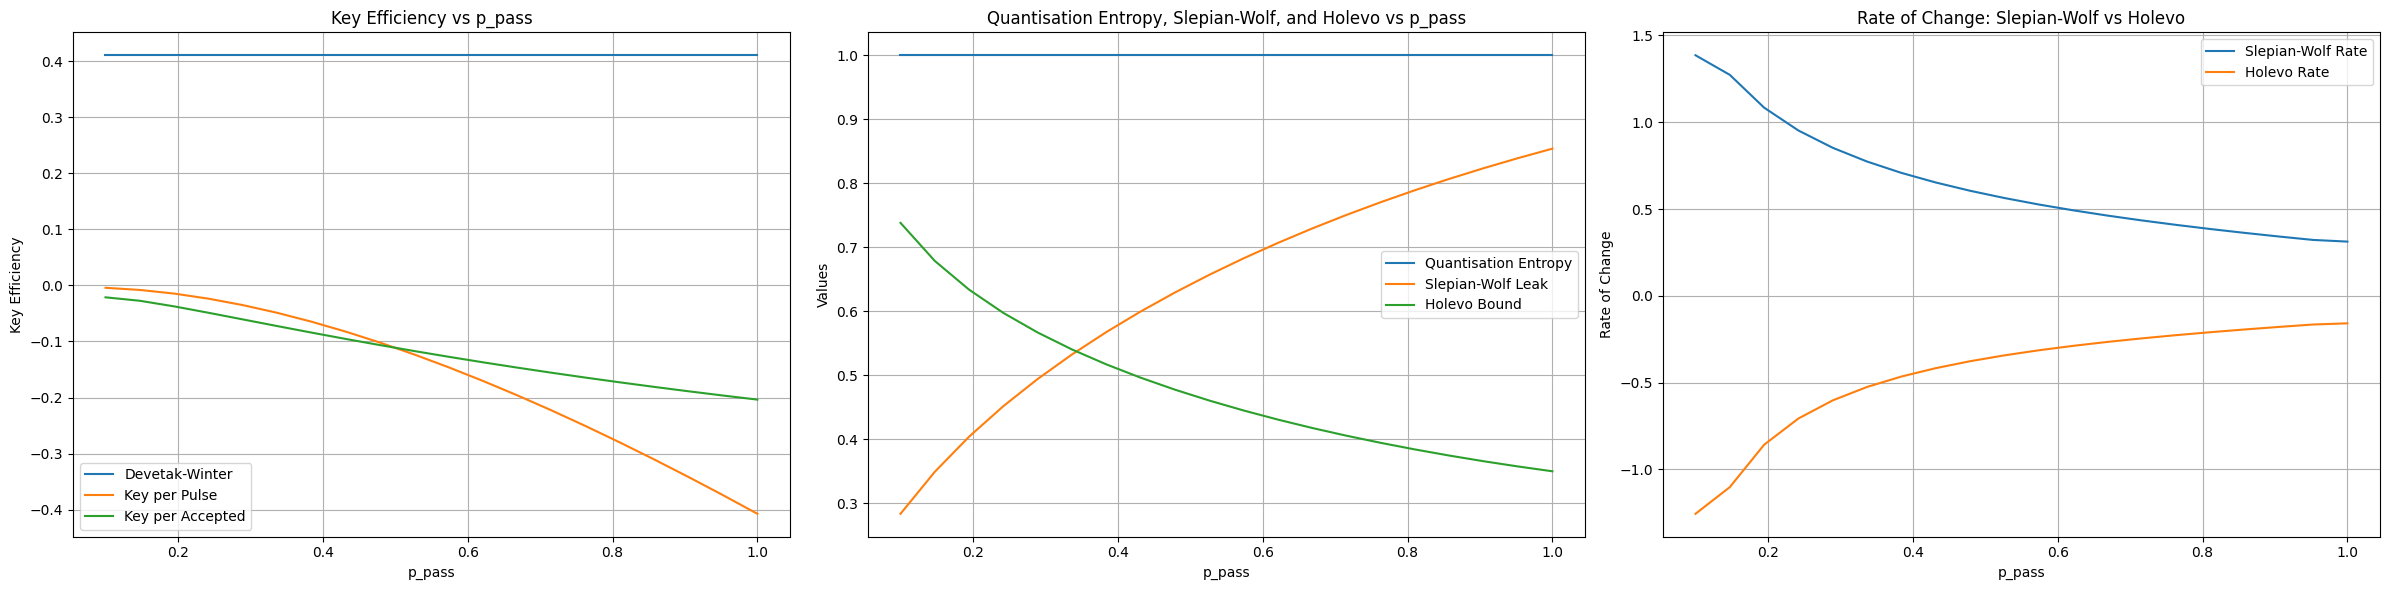

In [3]:
key_per_pulse_m1 = []
key_per_accepted_m1 = []
quantisation_entropies_m1 = []
slepian_wolf_leaks_m1 = []
holevo_bounds_m1 = []
mutual_informations_m1 = []
devetak_winters_m1 = []

distance = 10
excess_noise = 0.001
v_mod = 2.2
transmittance = fibre_transmittance(distance)

gbsr = GBSR(1, v_mod, transmittance, excess_noise)

devetak_winter = gbsr.continuous_devetak_winter

tau_arr = gbsr.build_equiprobable_tau()

# Loop over p_pass values
p_passes_arr = np.linspace(0.1, 1.0, 20)

for p_pass in p_passes_arr:
    g_arr = gbsr.generate_g_arr_from_p_pass(p_pass, tau_arr)
    
    # For each p_pass, evaluate the key efficiency
    metrics = gbsr.evaluate_quantised_maximum_key_efficiency(tau_arr, g_arr)
    key_per_pulse_m1.append(metrics['key_per_pulse'])
    key_per_accepted_m1.append(metrics['key_per_accepted_symbol'])
    quantisation_entropies_m1.append(metrics['H_Tx_acc'])
    slepian_wolf_leaks_m1.append(metrics['H_Tx_given_Ty'])
    holevo_bounds_m1.append(metrics['holevo_bound'])
    mutual_informations_m1.append(metrics['I_symbol'])
    devetak_winters_m1.append(devetak_winter)

fig, axes = plt.subplots(1, 3, figsize=(24, 6))

# Left subplot: Key rates
axes[0].plot(p_passes_arr, devetak_winters_m1, label='Devetak-Winter')
axes[0].plot(p_passes_arr, key_per_pulse_m1, label='Key per Pulse')
axes[0].plot(p_passes_arr, key_per_accepted_m1, label='Key per Accepted')
axes[0].set_xlabel('p_pass')
axes[0].set_ylabel('Key Efficiency')
axes[0].set_title('Key Efficiency vs p_pass')
axes[0].legend()
axes[0].grid(True)

# Middle subplot: Quantisation entropy, Slepian-Wolf leaks, and Holevo bounds
axes[1].plot(p_passes_arr, quantisation_entropies_m1, label='Quantisation Entropy')
axes[1].plot(p_passes_arr, slepian_wolf_leaks_m1, label='Slepian-Wolf Leak')
axes[1].plot(p_passes_arr, holevo_bounds_m1, label='Holevo Bound')
axes[1].set_xlabel('p_pass')
axes[1].set_ylabel('Values')
axes[1].set_title('Quantisation Entropy, Slepian-Wolf, and Holevo vs p_pass')
axes[1].legend()
axes[1].grid(True)

# Right subplot: Rate of change comparison
slepian_wolf_rate = np.gradient(slepian_wolf_leaks_m1, p_passes_arr)
holevo_rate = np.gradient(holevo_bounds_m1, p_passes_arr)
axes[2].plot(p_passes_arr, slepian_wolf_rate, label='Slepian-Wolf Rate')
axes[2].plot(p_passes_arr, holevo_rate, label='Holevo Rate')
axes[2].set_xlabel('p_pass')
axes[2].set_ylabel('Rate of Change')
axes[2].set_title('Rate of Change: Slepian-Wolf vs Holevo')
axes[2].legend()
axes[2].grid(True)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

    

## $m=1$ Optimal Parameters at 10km

In this part, we explore the above further. As shown in the plots, clearly, as we move away from $p_\text{pass} = 1$, the Slepian-Wolf leak decreases much quicker than the Holevo bound increases, leading to an overall increase in key efficiency.

Clearly $p_\text{pass}$ is one variable which can be optimised. However, we must also optimise $V_\text{mod}$ (for constant $m$, $\xi$ and $T$). In the next cell, we explore this surface.

Scanning V_mod:   0%|           | 0/100 [00:00<?, ?step/s]

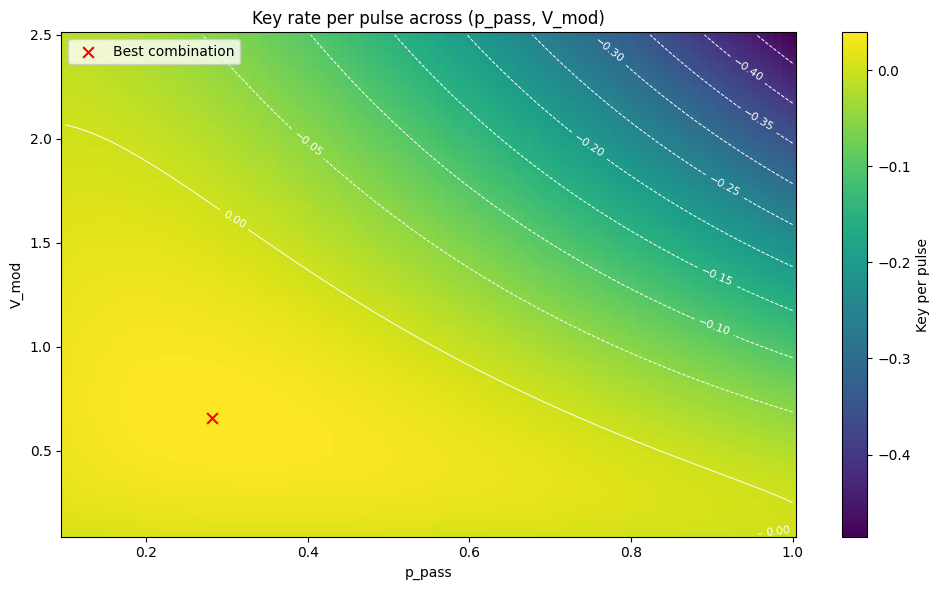

Best key per pulse: 3.9480e-02
  at V_mod = 0.658, p_pass = 0.282
  key per accepted symbol = 7.0045e-02
  Holevo bound = 1.3578e-01
  Slepian-Wolf leak = 7.9418e-01
  Mutual information = 2.0582e-01
  Acceptance probability p_pass = 2.8182e-01


In [4]:
# Explore K(p_pass, V_mod) surface to find optimal parameters and visualise the landscape.
v_mod_vals = np.linspace(0.1, 2.5, 100)
p_pass_vals = np.linspace(0.1, 1.0, 100)
key_surface = np.full((v_mod_vals.size, p_pass_vals.size), np.nan)
optimal_metrics_m1 = None
optimal_indices = (None, None)

for i, v_mod_candidate in tqdm(enumerate(v_mod_vals), total=len(v_mod_vals), desc="Scanning V_mod", unit="step", bar_format="{l_bar}{bar} | {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]"):
    gbsr_candidate = GBSR(1, v_mod_candidate, transmittance, excess_noise)
    tau_candidate = gbsr_candidate.build_equiprobable_tau()
    for j, p_pass_candidate in enumerate(p_pass_vals):
        try:
            g_candidate = gbsr_candidate.generate_g_arr_from_p_pass(p_pass_candidate, tau_candidate)
            metrics_candidate = gbsr_candidate.evaluate_quantised_maximum_key_efficiency(tau_candidate, g_candidate)
        except Exception as exc:
            # Some parameter pairs may be infeasible; skip them but keep the surface structured.
            continue
        key_surface[i, j] = metrics_candidate["key_per_pulse"]
        if optimal_metrics_m1 is None or metrics_candidate["key_per_pulse"] > optimal_metrics_m1["key_per_pulse"]:
            optimal_metrics_m1 = metrics_candidate
            optimal_indices = (i, j)

if optimal_metrics_m1 is None:
    raise RuntimeError("No valid parameter pairs encountered when scanning the grid.")

best_v_mod = float(v_mod_vals[optimal_indices[0]])
best_p_pass = float(p_pass_vals[optimal_indices[1]])

V_mesh, P_mesh = np.meshgrid(v_mod_vals, p_pass_vals, indexing="ij")
fig, ax = plt.subplots(figsize=(10, 6))
heatmap = ax.pcolormesh(P_mesh, V_mesh, key_surface, shading="nearest", cmap="viridis")
contours = ax.contour(P_mesh, V_mesh, key_surface, levels=10, colors="white", linewidths=0.7)
ax.clabel(contours, inline=True, fontsize=8)
ax.scatter([best_p_pass], [best_v_mod], color="red", marker="x", s=60, label="Best combination")
ax.set_xlabel("p_pass")
ax.set_ylabel("V_mod")
ax.set_title("Key rate per pulse across (p_pass, V_mod)")
ax.legend()
fig.colorbar(heatmap, ax=ax, label="Key per pulse")
plt.tight_layout()
plt.show()

print(f"Best key per pulse: {optimal_metrics_m1['key_per_pulse']:.4e}")
print(f"  at V_mod = {best_v_mod:.3f}, p_pass = {best_p_pass:.3f}")
print(f"  key per accepted symbol = {optimal_metrics_m1['key_per_accepted_symbol']:.4e}")
print(f"  Holevo bound = {optimal_metrics_m1['holevo_bound']:.4e}")
print(f"  Slepian-Wolf leak = {optimal_metrics_m1['H_Tx_given_Ty']:.4e}")
print(f"  Mutual information = {optimal_metrics_m1['I_symbol']:.4e}")
print(f"  Acceptance probability p_pass = {optimal_metrics_m1['p_pass']:.4e}")

## $m=1$ Optimal Key Efficiency over Distance 

Next, we are attempting to show what the optimal key efficiency is over distance when optimising both $p_\text{pass}$ and $V_\text{mod}$ for each distance. For the found $V_\text{mod}$, we also show the corresponding Devetak-Winter rate.

Optimising per distance:   0%|          | 0/60 [00:00<?, ?it/s]

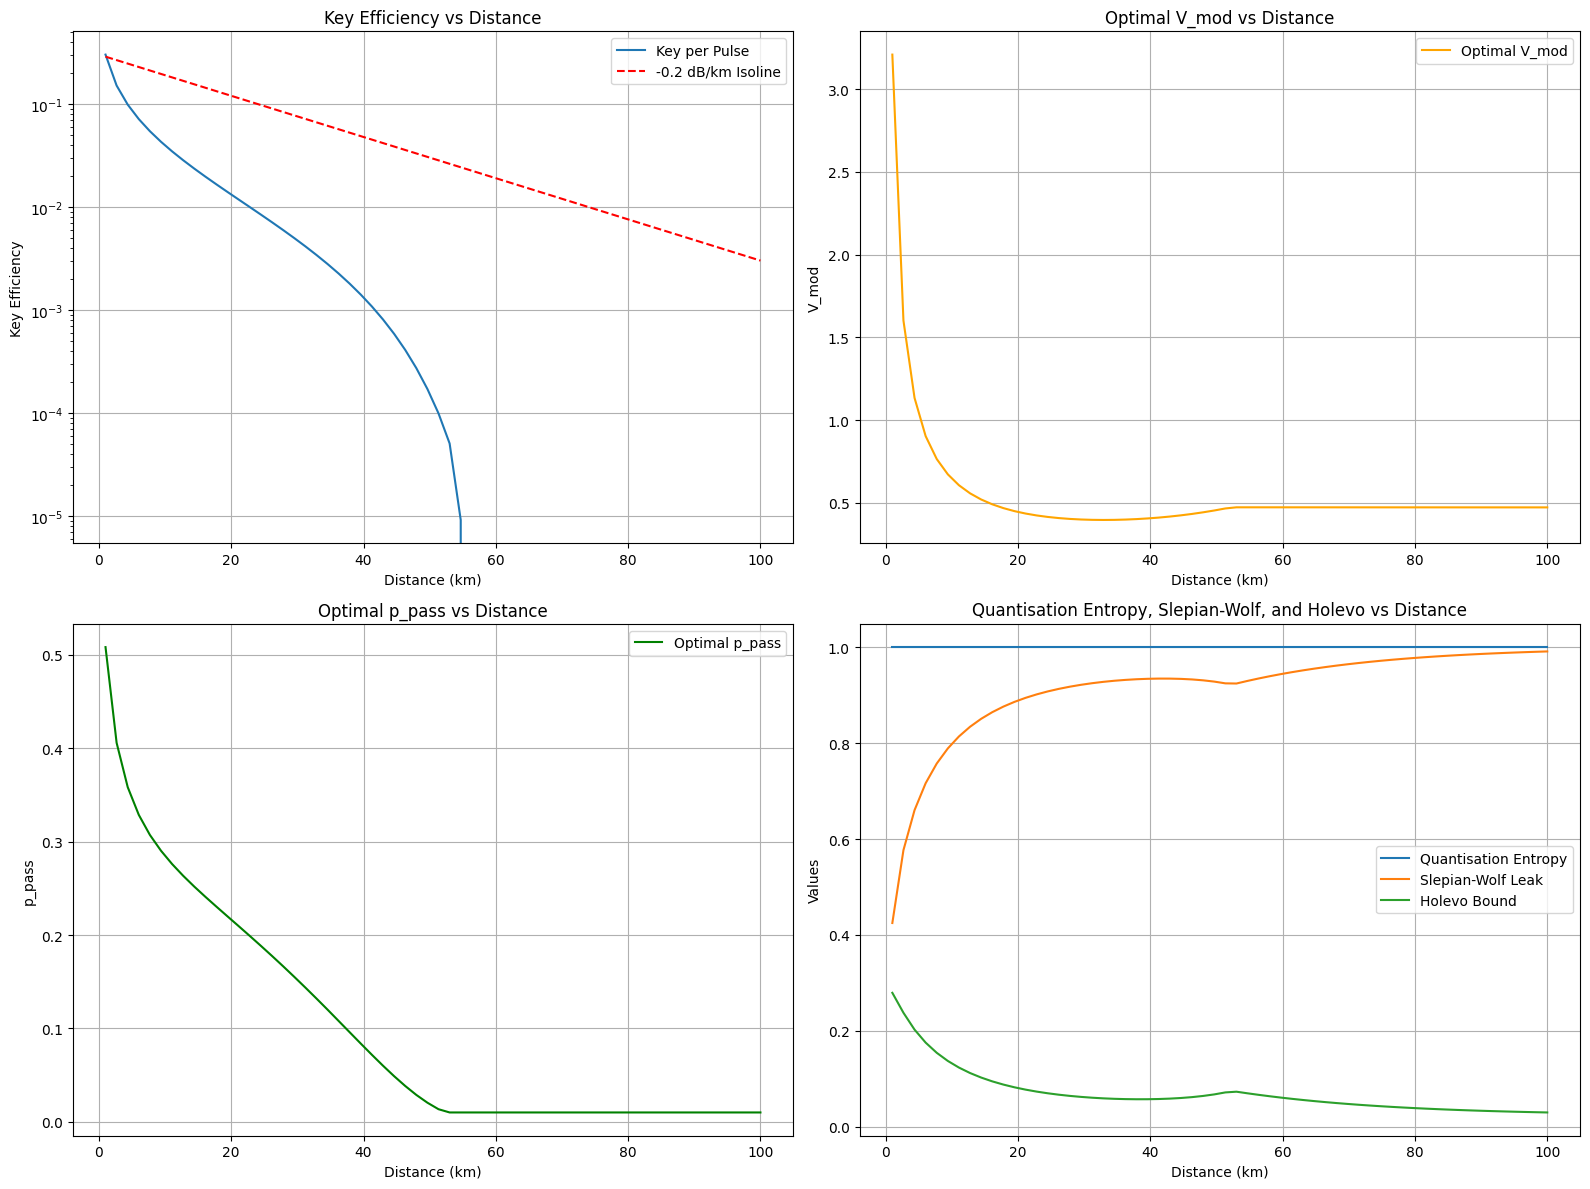

In [5]:
key_per_pulse_m1 = []
key_per_accepted_m1 = []
quantisation_entropies_m1 = []
slepian_wolf_leaks_m1 = []
holevo_bounds_m1 = []
mutual_informations_m1 = []
devetak_winters_m1 = []
optimal_v_mods_m1 = []
optimal_p_passes_m1 = []
optimal_metrics_m1 = []

initial_guess = np.array([np.mean(v_mod_bounds), 0.8])
bounds = [v_mod_bounds, p_pass_bounds]

for distance in tqdm(distances, desc="Optimising per distance"):
    transmittance = fibre_transmittance(distance)

    def evaluate_metrics(v_mod_candidate: float, p_pass_candidate: float):
        gbsr_instance = GBSR(1, float(v_mod_candidate), transmittance, excess_noise)
        tau_arr = gbsr_instance.build_equiprobable_tau()
        g_arr = gbsr_instance.generate_g_arr_from_p_pass(float(p_pass_candidate), tau_arr)
        metrics = gbsr_instance.evaluate_quantised_maximum_key_efficiency(tau_arr, g_arr)
        return dict(metrics), gbsr_instance

    def negative_key_per_pulse(params):
        v_mod_candidate, p_pass_candidate = params
        v_mod_checked = float(np.clip(v_mod_candidate, *v_mod_bounds))
        p_pass_checked = float(np.clip(p_pass_candidate, *p_pass_bounds))
        try:
            metrics_candidate, _ = evaluate_metrics(v_mod_checked, p_pass_checked)
        except Exception:
            return np.inf
        return -metrics_candidate["key_per_pulse"]

    optimisation_result = minimize(
        negative_key_per_pulse,
        x0=initial_guess,
        bounds=bounds,
        method="L-BFGS-B",
    )

    if not optimisation_result.success or not np.isfinite(optimisation_result.fun):
        grid_v_mod = np.linspace(v_mod_bounds[0], v_mod_bounds[1], 25)
        grid_p_pass = np.linspace(p_pass_bounds[0], p_pass_bounds[1], 25)
        best_value = np.inf
        best_pair = None
        for v_candidate in grid_v_mod:
            for p_candidate in grid_p_pass:
                value = negative_key_per_pulse((v_candidate, p_candidate))
                if value < best_value:
                    best_value = value
                    best_pair = (v_candidate, p_candidate)
        if best_pair is None:
            raise RuntimeError(f"Failed to find feasible parameters at distance {distance:.2f} km")
        best_v_mod, best_p_pass = best_pair
    else:
        best_v_mod, best_p_pass = optimisation_result.x

    best_v_mod = float(np.clip(best_v_mod, *v_mod_bounds))
    best_p_pass = float(np.clip(best_p_pass, *p_pass_bounds))
    best_metrics, best_gbsr_instance = evaluate_metrics(best_v_mod, best_p_pass)

    key_per_pulse_m1.append(best_metrics["key_per_pulse"])
    key_per_accepted_m1.append(best_metrics["key_per_accepted_symbol"])
    quantisation_entropies_m1.append(best_metrics["H_Tx_acc"])
    slepian_wolf_leaks_m1.append(best_metrics["H_Tx_given_Ty"])
    holevo_bounds_m1.append(best_metrics["holevo_bound"])
    mutual_informations_m1.append(best_metrics["I_symbol"])
    devetak_winters_m1.append(best_gbsr_instance.continuous_devetak_winter)
    optimal_v_mods_m1.append(best_v_mod)
    optimal_p_passes_m1.append(best_p_pass)

    optimal_metrics_m1.append(best_metrics)
    initial_guess = np.array([best_v_mod, best_p_pass])

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# First subplot: key_per_pulse and devetak_winter vs distance
axes[0, 0].plot(distances, key_per_pulse_m1, label='Key per Pulse')
#axes[0, 0].plot(distances, devetak_winters_m1, label='Devetak-Winter')

# Add an isoline corresponding to a slope of -0.2 dB/km
isoline = key_per_pulse_m1[0] * 10 ** (-0.2 * distances / 10)
axes[0, 0].plot(distances, isoline, label='-0.2 dB/km Isoline', linestyle='--', color='red')

axes[0, 0].set_xlabel('Distance (km)')
axes[0, 0].set_ylabel('Key Efficiency')
axes[0, 0].set_title('Key Efficiency vs Distance')
axes[0, 0].set_yscale('log')  # Set y-axis to log scale
axes[0, 0].legend()
axes[0, 0].grid(True)

# Second subplot: optimal V_mod over distance
axes[0, 1].plot(distances, optimal_v_mods_m1, label='Optimal V_mod', color='orange')
axes[0, 1].set_xlabel('Distance (km)')
axes[0, 1].set_ylabel('V_mod')
axes[0, 1].set_title('Optimal V_mod vs Distance')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Third subplot: optimal p_pass over distance
axes[1, 0].plot(distances, optimal_p_passes_m1, label='Optimal p_pass', color='green')
axes[1, 0].set_xlabel('Distance (km)')
axes[1, 0].set_ylabel('p_pass')
axes[1, 0].set_title('Optimal p_pass vs Distance')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Fourth subplot: quantisation_entropy, slepian_wolf_leak, holevo_bound vs distance
axes[1, 1].plot(distances, quantisation_entropies_m1, label='Quantisation Entropy')
axes[1, 1].plot(distances, slepian_wolf_leaks_m1, label='Slepian-Wolf Leak')
axes[1, 1].plot(distances, holevo_bounds_m1, label='Holevo Bound')
axes[1, 1].set_xlabel('Distance (km)')
axes[1, 1].set_ylabel('Values')
axes[1, 1].set_title('Quantisation Entropy, Slepian-Wolf, and Holevo vs Distance')
axes[1, 1].legend()
axes[1, 1].grid(True)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

Next, for comparison, we complete the same analysis but for the constraint that $p_\text{pass} = 1$ (i.e. no postselection). This will allow us to see the advantage gained by optimising $p_\text{pass}$ alongside $V_\text{mod}$. We only need to store the key rate and the optimal v_mod in this case.

Optimising V_mod (no postselection):   0%|          | 0/60 [00:00<?, ?it/s]

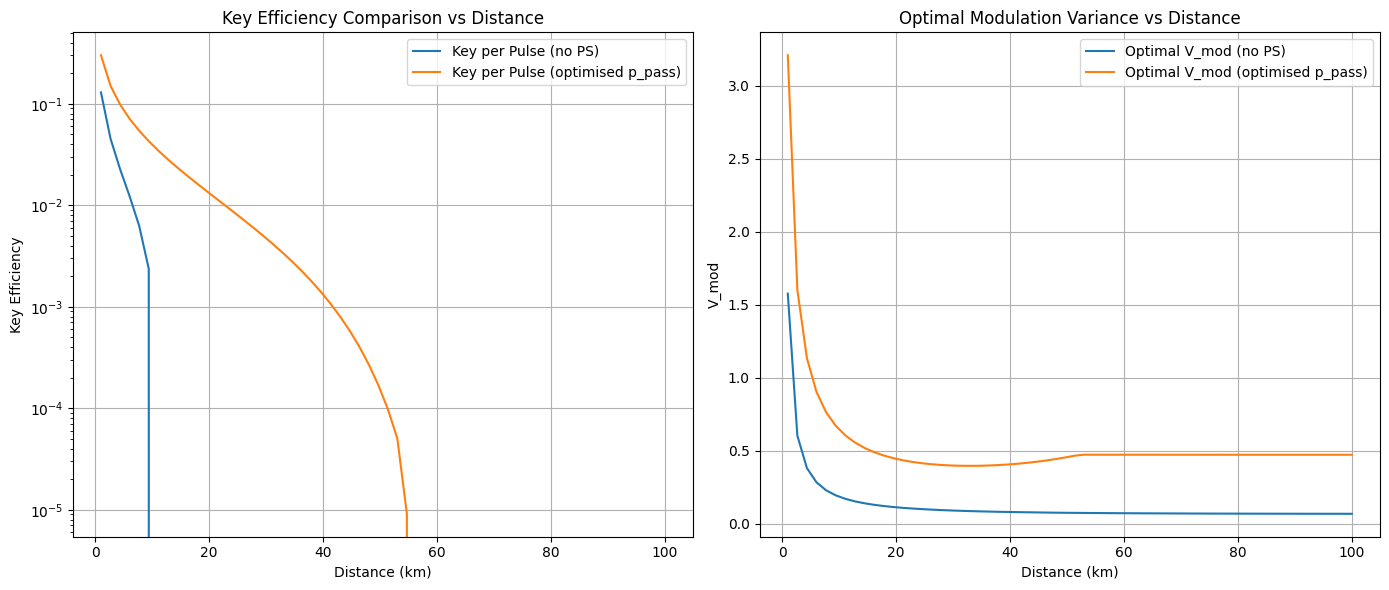

In [6]:
key_per_pulse_no_ps_m1 = []
devetak_winters_no_ps_m1 = []
optimal_v_mods_no_ps_m1 = []
devetak_winter_no_ps_m1 = []

def evaluate_no_ps_metrics(v_mod_candidate: float, transmittance: float):
    gbsr_instance = GBSR(1, float(v_mod_candidate), transmittance, excess_noise)
    tau_arr = gbsr_instance.build_equiprobable_tau()
    g_arr = gbsr_instance.generate_g_arr_from_p_pass(1.0, tau_arr)
    metrics = gbsr_instance.evaluate_quantised_maximum_key_efficiency(tau_arr, g_arr)
    return dict(metrics), gbsr_instance

for distance in tqdm(distances, desc="Optimising V_mod (no postselection)"):
    transmittance = fibre_transmittance(distance)

    def negative_key_no_ps(v_mod_candidate: float) -> float:
        v_mod_checked = float(np.clip(v_mod_candidate, *v_mod_bounds))
        try:
            metrics_candidate, _ = evaluate_no_ps_metrics(v_mod_checked, transmittance)
        except Exception:
            return np.inf
        return -metrics_candidate["key_per_pulse"]

    optimisation_result = minimize_scalar(
        negative_key_no_ps,
        bounds=v_mod_bounds,
        method="bounded",
        options={"xatol": 1e-3},
    )

    if not optimisation_result.success or not np.isfinite(optimisation_result.fun):
        candidate_v_mods = np.linspace(v_mod_bounds[0], v_mod_bounds[1], 50)
        best_value = np.inf
        best_v_mod = None
        for v_candidate in candidate_v_mods:
            value = negative_key_no_ps(v_candidate)
            if value < best_value:
                best_value = value
                best_v_mod = v_candidate
        if best_v_mod is None:
            raise RuntimeError(f"Failed to optimise V_mod for distance {distance:.2f} km with p_pass = 1")
    else:
        best_v_mod = optimisation_result.x

    best_v_mod = float(np.clip(best_v_mod, *v_mod_bounds))
    best_metrics, best_gbsr = evaluate_no_ps_metrics(best_v_mod, transmittance)

    key_per_pulse_no_ps_m1.append(best_metrics["key_per_pulse"])
    devetak_winters_no_ps_m1.append(best_gbsr.continuous_devetak_winter)
    optimal_v_mods_no_ps_m1.append(best_v_mod)
    devetak_winter_no_ps_m1.append(best_gbsr.continuous_devetak_winter)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(distances, key_per_pulse_no_ps_m1, label='Key per Pulse (no PS)')
axes[0].plot(distances, key_per_pulse_m1, label='Key per Pulse (optimised p_pass)')
#axes[0].plot(distances, devetak_winter_no_ps_m1, label='Devetak-Winter (no PS)')
#axes[0].plot(distances, devetak_winters_m1, label='Devetak-Winter (optimised p_pass)')
axes[0].set_xlabel('Distance (km)')
axes[0].set_ylabel('Key Efficiency')
axes[0].set_title('Key Efficiency Comparison vs Distance')
axes[0].set_yscale('log')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(distances, optimal_v_mods_no_ps_m1, label='Optimal V_mod (no PS)')
axes[1].plot(distances, optimal_v_mods_m1, label='Optimal V_mod (optimised p_pass)')
axes[1].set_xlabel('Distance (km)')
axes[1].set_ylabel('V_mod')
axes[1].set_title('Optimal Modulation Variance vs Distance')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## $m=2$

Next, we explore the $m=2$ case. There's a complication now. There are now three variables to optimise. $V_\text{mod}$, $p_\text{pass}$ and $\tau_3$. We know that $\tau_0 = -\infty$, $\tau_1 = -\tau_3$, $\tau_2 = 0$ and $\tau_4 = \infty$. However, for simplicity for now, we will assume equiprobable intervals.

In [7]:
"""
# Optimise V_mod, p_pass, and tau_3 jointly for m = 2.
key_per_pulse_full_m2 = []
key_per_accepted_full_m2 = []
quantisation_entropies_full_m2 = []
slepian_wolf_leaks_full_m2 = []
holevo_bounds_full_m2 = []
mutual_informations_full_m2 = []
devetak_winters_full_m2 = []
optimal_v_mods_full_m2 = []
optimal_p_passes_full_m2 = []
optimal_tau3_full_m2 = []
optimal_metrics_full_m2 = []
execution_times_full_m2 = []

tau3_bounds = (0.1, 4.0)
initial_guess_full = np.array([np.mean(v_mod_bounds), 0.8, np.mean(tau3_bounds)])
bounds_full = [v_mod_bounds, p_pass_bounds, tau3_bounds]

for distance in tqdm(distances, desc='Optimising per distance (m=2, full)'):
    start_time = time.perf_counter()
    transmittance = fibre_transmittance(distance)

    def evaluate_metrics_full(v_mod_candidate: float, p_pass_candidate: float, tau3_candidate: float):
        gbsr_instance = GBSR(2, float(v_mod_candidate), transmittance, excess_noise)
        tau3_value = float(np.clip(tau3_candidate, *tau3_bounds))
        tau_arr = np.array([-np.inf, -tau3_value, 0.0, tau3_value, np.inf], dtype=float)
        g_arr = gbsr_instance.generate_g_arr_from_p_pass(float(p_pass_candidate), tau_arr)
        metrics = gbsr_instance.evaluate_quantised_maximum_key_efficiency(tau_arr, g_arr)
        return dict(metrics), gbsr_instance

    def negative_key_full(params):
        v_mod_candidate, p_pass_candidate, tau3_candidate = params
        v_mod_checked = float(np.clip(v_mod_candidate, *v_mod_bounds))
        p_pass_checked = float(np.clip(p_pass_candidate, *p_pass_bounds))
        tau3_checked = float(np.clip(tau3_candidate, *tau3_bounds))
        if tau3_checked <= 0.0:
            return np.inf
        try:
            metrics_candidate, _ = evaluate_metrics_full(v_mod_checked, p_pass_checked, tau3_checked)
        except Exception:
            return np.inf
        return -metrics_candidate['key_per_pulse']

    optimisation_result = minimize(
        negative_key_full,
        x0=initial_guess_full,
        bounds=bounds_full,
        method='Powell',
    )

    if not optimisation_result.success or not np.isfinite(optimisation_result.fun):
        grid_v_mod = np.linspace(v_mod_bounds[0], v_mod_bounds[1], 12)
        grid_p_pass = np.linspace(p_pass_bounds[0], p_pass_bounds[1], 12)
        grid_tau3 = np.linspace(tau3_bounds[0], tau3_bounds[1], 12)
        best_value = np.inf
        best_triplet = None
        for v_candidate in grid_v_mod:
            for p_candidate in grid_p_pass:
                for tau_candidate in grid_tau3:
                    value = negative_key_full((v_candidate, p_candidate, tau_candidate))
                    if value < best_value:
                        best_value = value
                        best_triplet = (v_candidate, p_candidate, tau_candidate)
        if best_triplet is None:
            raise RuntimeError(f'Failed to find feasible parameters at distance {distance:.2f} km for m=2 (full)')
        best_v_mod, best_p_pass, best_tau3 = best_triplet
    else:
        best_v_mod, best_p_pass, best_tau3 = optimisation_result.x

    best_v_mod = float(np.clip(best_v_mod, *v_mod_bounds))
    best_p_pass = float(np.clip(best_p_pass, *p_pass_bounds))
    best_tau3 = float(np.clip(best_tau3, *tau3_bounds))

    best_metrics, best_gbsr_instance = evaluate_metrics_full(best_v_mod, best_p_pass, best_tau3)

    key_per_pulse_full_m2.append(best_metrics['key_per_pulse'])
    key_per_accepted_full_m2.append(best_metrics['key_per_accepted_symbol'])
    quantisation_entropies_full_m2.append(best_metrics['H_Tx_acc'])
    slepian_wolf_leaks_full_m2.append(best_metrics['H_Tx_given_Ty'])
    holevo_bounds_full_m2.append(best_metrics['holevo_bound'])
    mutual_informations_full_m2.append(best_metrics['I_symbol'])
    devetak_winters_full_m2.append(best_gbsr_instance.continuous_devetak_winter)
    optimal_v_mods_full_m2.append(best_v_mod)
    optimal_p_passes_full_m2.append(best_metrics['p_pass'])
    optimal_tau3_full_m2.append(best_tau3)
    optimal_metrics_full_m2.append(best_metrics)
    execution_times_full_m2.append(time.perf_counter() - start_time)

    initial_guess_full = np.array([best_v_mod, best_p_pass, best_tau3])

distances_arr = np.asarray(distances, dtype=float)
key_per_pulse_full_m2_arr = np.asarray(key_per_pulse_full_m2, dtype=float)
key_per_accepted_full_m2_arr = np.asarray(key_per_accepted_full_m2, dtype=float)
quantisation_entropies_full_m2_arr = np.asarray(quantisation_entropies_full_m2, dtype=float)
slepian_wolf_leaks_full_m2_arr = np.asarray(slepian_wolf_leaks_full_m2, dtype=float)
holevo_bounds_full_m2_arr = np.asarray(holevo_bounds_full_m2, dtype=float)
mutual_informations_full_m2_arr = np.asarray(mutual_informations_full_m2, dtype=float)
devetak_winters_full_m2_arr = np.asarray(devetak_winters_full_m2, dtype=float)
optimal_v_mods_full_m2_arr = np.asarray(optimal_v_mods_full_m2, dtype=float)
optimal_p_passes_full_m2_arr = np.asarray(optimal_p_passes_full_m2, dtype=float)
optimal_tau3_full_m2_arr = np.asarray(optimal_tau3_full_m2, dtype=float)
execution_times_full_m2_arr = np.asarray(execution_times_full_m2, dtype=float)

fig, axes = plt.subplots(2, 3, figsize=(22, 10))

axes[0, 0].plot(distances_arr, key_per_pulse_full_m2_arr, label='Key per Pulse')
axes[0, 0].plot(distances_arr, devetak_winters_full_m2_arr, label='Devetak-Winter')
positive_mask = key_per_pulse_full_m2_arr > 0.0
if np.any(positive_mask):
    first_positive_idx = np.argmax(positive_mask)
    reference_value = key_per_pulse_full_m2_arr[first_positive_idx]
    isoline_full = reference_value * 10 ** (-0.2 * (distances_arr - distances_arr[first_positive_idx]) / 10)
    axes[0, 0].plot(distances_arr, isoline_full, linestyle='--', color='red', label='-0.2 dB/km Isoline')
axes[0, 0].set_xlabel('Distance (km)')
axes[0, 0].set_ylabel('Key Efficiency')
axes[0, 0].set_title('Key Efficiency vs Distance (m=2, full)')
axes[0, 0].set_yscale('log')
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].plot(distances_arr, optimal_v_mods_full_m2_arr, color='orange', label='Optimal V_mod')
axes[0, 1].set_xlabel('Distance (km)')
axes[0, 1].set_ylabel('V_mod')
axes[0, 1].set_title('Optimal V_mod (m=2, full)')
axes[0, 1].legend()
axes[0, 1].grid(True)

axes[0, 2].plot(distances_arr, optimal_tau3_full_m2_arr, color='purple', label='Optimal tau_3')
axes[0, 2].set_xlabel('Distance (km)')
axes[0, 2].set_ylabel('tau_3 (sigma units)')
axes[0, 2].set_title('Optimal tau_3 (m=2, full)')
axes[0, 2].legend()
axes[0, 2].grid(True)

axes[1, 0].plot(distances_arr, optimal_p_passes_full_m2_arr, color='green', label='Optimal p_pass')
axes[1, 0].set_xlabel('Distance (km)')
axes[1, 0].set_ylabel('p_pass')
axes[1, 0].set_title('Optimal p_pass (m=2, full)')
axes[1, 0].legend()
axes[1, 0].grid(True)

axes[1, 1].plot(distances_arr, quantisation_entropies_full_m2_arr, label='Quantisation Entropy')
axes[1, 1].plot(distances_arr, slepian_wolf_leaks_full_m2_arr, label='Slepian-Wolf Leak')
axes[1, 1].plot(distances_arr, holevo_bounds_full_m2_arr, label='Holevo Bound')
axes[1, 1].set_xlabel('Distance (km)')
axes[1, 1].set_ylabel('Values')
axes[1, 1].set_title('Entropy and Leakage Terms')
axes[1, 1].legend()
axes[1, 1].grid(True)

axes[1, 2].plot(distances_arr, key_per_accepted_full_m2_arr, label='Key per Accepted')
axes[1, 2].plot(distances_arr, mutual_informations_full_m2_arr, label='I_symbol')
axes[1, 2].set_xlabel('Distance (km)')
axes[1, 2].set_ylabel('Bits per Accepted Symbol')
axes[1, 2].set_title('Symbol Metrics')
axes[1, 2].legend()
axes[1, 2].grid(True)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(distances_arr, execution_times_full_m2_arr, marker='o')
plt.xlabel('Distance (km)')
plt.ylabel('Execution time per distance (s)')
plt.title('Optimisation Runtime vs Distance (m=2, full)')
plt.grid(True)
plt.tight_layout()
plt.show()
"""

"\n# Optimise V_mod, p_pass, and tau_3 jointly for m = 2.\nkey_per_pulse_full_m2 = []\nkey_per_accepted_full_m2 = []\nquantisation_entropies_full_m2 = []\nslepian_wolf_leaks_full_m2 = []\nholevo_bounds_full_m2 = []\nmutual_informations_full_m2 = []\ndevetak_winters_full_m2 = []\noptimal_v_mods_full_m2 = []\noptimal_p_passes_full_m2 = []\noptimal_tau3_full_m2 = []\noptimal_metrics_full_m2 = []\nexecution_times_full_m2 = []\n\ntau3_bounds = (0.1, 4.0)\ninitial_guess_full = np.array([np.mean(v_mod_bounds), 0.8, np.mean(tau3_bounds)])\nbounds_full = [v_mod_bounds, p_pass_bounds, tau3_bounds]\n\nfor distance in tqdm(distances, desc='Optimising per distance (m=2, full)'):\n    start_time = time.perf_counter()\n    transmittance = fibre_transmittance(distance)\n\n    def evaluate_metrics_full(v_mod_candidate: float, p_pass_candidate: float, tau3_candidate: float):\n        gbsr_instance = GBSR(2, float(v_mod_candidate), transmittance, excess_noise)\n        tau3_value = float(np.clip(tau3_can

Optimising per distance (m=2):   0%|          | 0/60 [00:00<?, ?it/s]

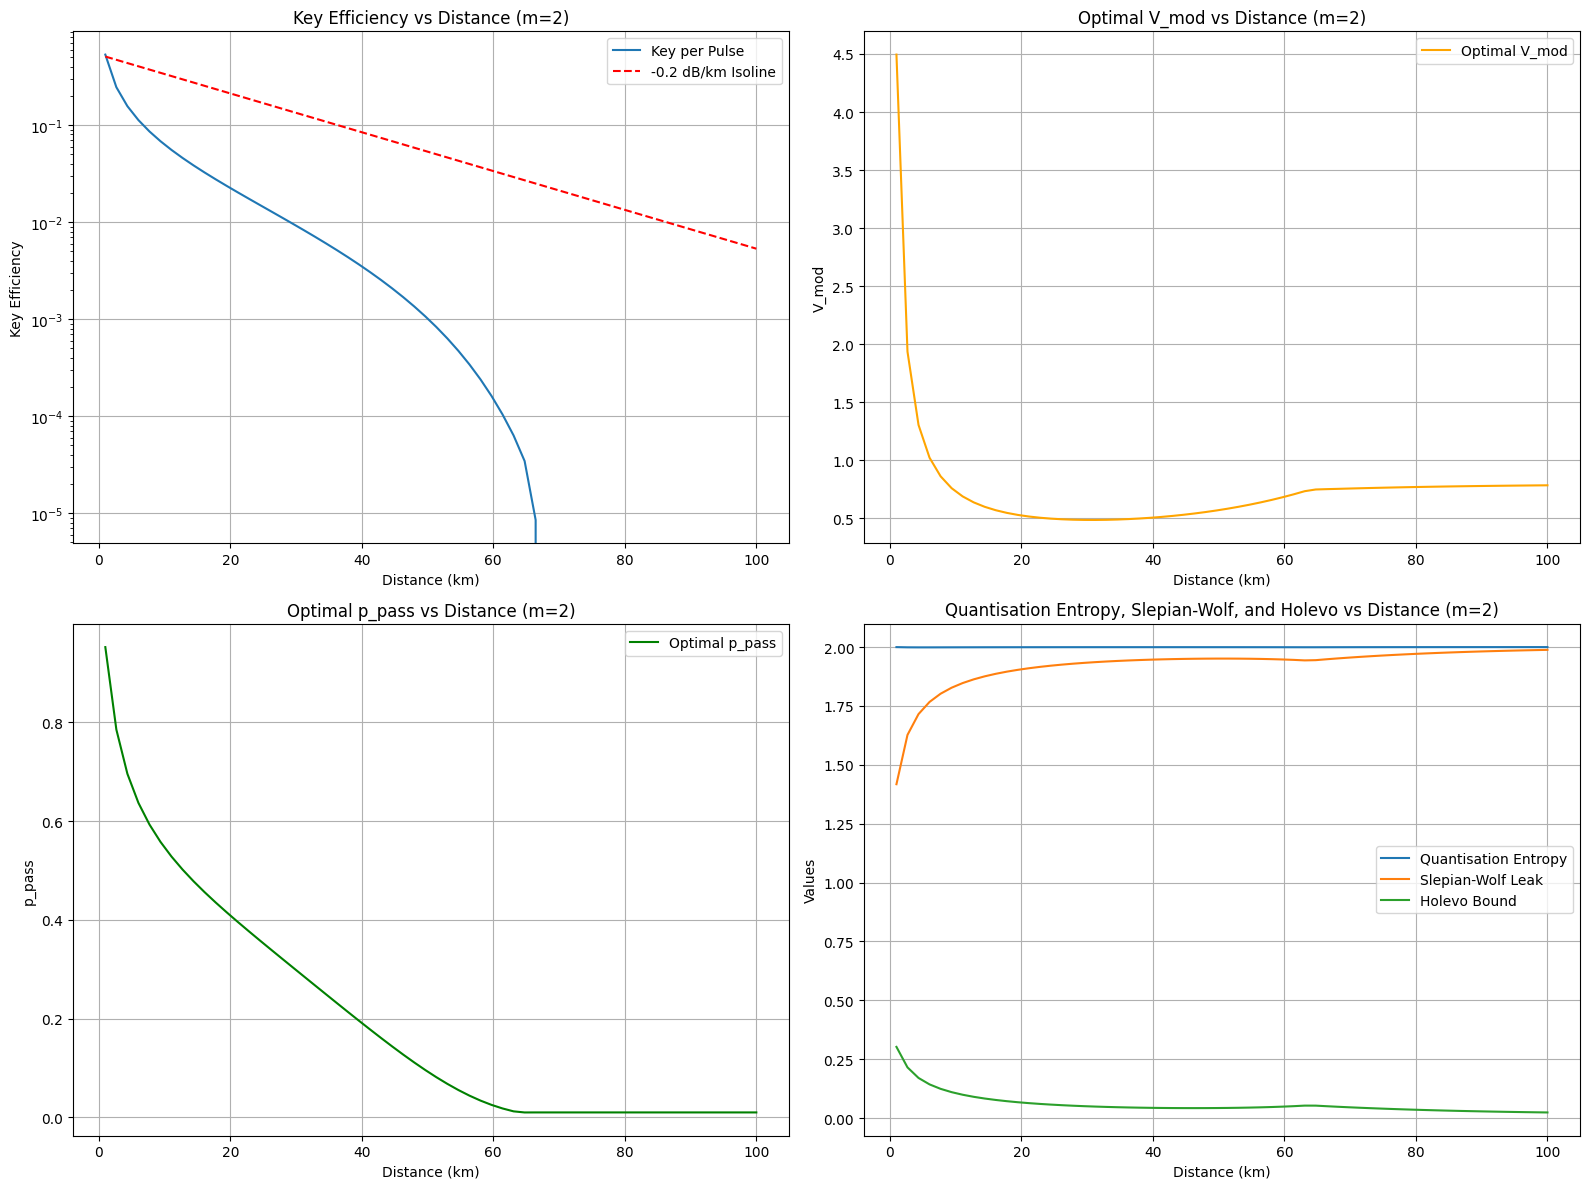

In [8]:
key_per_pulse_m2 = []
key_per_accepted_m2 = []
quantisation_entropies_m2 = []
slepian_wolf_leaks_m2 = []
holevo_bounds_m2 = []
mutual_informations_m2 = []
devetak_winters_m2 = []
optimal_v_mods_m2 = []
optimal_p_passes_m2 = []
optimal_metrics_m2 = []

initial_guess_m2 = np.array([np.mean(v_mod_bounds), 0.8])
bounds_m2 = [v_mod_bounds, p_pass_bounds]

for distance in tqdm(distances, desc="Optimising per distance (m=2)"):
    transmittance = fibre_transmittance(distance)

    def evaluate_metrics(v_mod_candidate: float, p_pass_candidate: float):
        gbsr_instance = GBSR(2, float(v_mod_candidate), transmittance, excess_noise)
        tau_arr = gbsr_instance.build_equiprobable_tau()
        g_arr = gbsr_instance.generate_g_arr_from_p_pass(float(p_pass_candidate), tau_arr)
        metrics = gbsr_instance.evaluate_quantised_maximum_key_efficiency(tau_arr, g_arr)
        return dict(metrics), gbsr_instance

    def negative_key_per_pulse(params):
        v_mod_candidate, p_pass_candidate = params
        v_mod_checked = float(np.clip(v_mod_candidate, *v_mod_bounds))
        p_pass_checked = float(np.clip(p_pass_candidate, *p_pass_bounds))
        try:
            metrics_candidate, _ = evaluate_metrics(v_mod_checked, p_pass_checked)
        except Exception:
            return np.inf
        return -metrics_candidate["key_per_pulse"]

    optimisation_result = minimize(
        negative_key_per_pulse,
        x0=initial_guess_m2,
        bounds=bounds_m2,
        method="Powell",
    )

    if not optimisation_result.success or not np.isfinite(optimisation_result.fun):
        grid_v_mod = np.linspace(v_mod_bounds[0], v_mod_bounds[1], 25)
        grid_p_pass = np.linspace(p_pass_bounds[0], p_pass_bounds[1], 25)
        best_value = np.inf
        best_pair = None
        for v_candidate in grid_v_mod:
            for p_candidate in grid_p_pass:
                value = negative_key_per_pulse((v_candidate, p_candidate))
                if value < best_value:
                    best_value = value
                    best_pair = (v_candidate, p_candidate)
        if best_pair is None:
            raise RuntimeError(f"Failed to find feasible parameters at distance {distance:.2f} km for m=2")
        best_v_mod, best_p_pass = best_pair
    else:
        best_v_mod, best_p_pass = optimisation_result.x

    best_v_mod = float(np.clip(best_v_mod, *v_mod_bounds))
    best_p_pass = float(np.clip(best_p_pass, *p_pass_bounds))
    best_metrics, best_gbsr_instance = evaluate_metrics(best_v_mod, best_p_pass)

    key_per_pulse_m2.append(best_metrics["key_per_pulse"])
    key_per_accepted_m2.append(best_metrics["key_per_accepted_symbol"])
    quantisation_entropies_m2.append(best_metrics["H_Tx_acc"])
    slepian_wolf_leaks_m2.append(best_metrics["H_Tx_given_Ty"])
    holevo_bounds_m2.append(best_metrics["holevo_bound"])
    mutual_informations_m2.append(best_metrics["I_symbol"])
    devetak_winters_m2.append(best_gbsr_instance.continuous_devetak_winter)
    optimal_v_mods_m2.append(best_v_mod)
    optimal_p_passes_m2.append(best_p_pass)

    optimal_metrics_m2.append(best_metrics)
    initial_guess_m2 = np.array([best_v_mod, best_p_pass])

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].plot(distances, key_per_pulse_m2, label='Key per Pulse')
#axes[0, 0].plot(distances, devetak_winters_m2, label='Devetak-Winter')
isoline_m2 = key_per_pulse_m2[0] * 10 ** (-0.2 * distances / 10)
axes[0, 0].plot(distances, isoline_m2, label='-0.2 dB/km Isoline', linestyle='--', color='red')
axes[0, 0].set_xlabel('Distance (km)')
axes[0, 0].set_ylabel('Key Efficiency')
axes[0, 0].set_title('Key Efficiency vs Distance (m=2)')
axes[0, 0].set_yscale('log')
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].plot(distances, optimal_v_mods_m2, label='Optimal V_mod', color='orange')
axes[0, 1].set_xlabel('Distance (km)')
axes[0, 1].set_ylabel('V_mod')
axes[0, 1].set_title('Optimal V_mod vs Distance (m=2)')
axes[0, 1].legend()
axes[0, 1].grid(True)

axes[1, 0].plot(distances, optimal_p_passes_m2, label='Optimal p_pass', color='green')
axes[1, 0].set_xlabel('Distance (km)')
axes[1, 0].set_ylabel('p_pass')
axes[1, 0].set_title('Optimal p_pass vs Distance (m=2)')
axes[1, 0].legend()
axes[1, 0].grid(True)

axes[1, 1].plot(distances, quantisation_entropies_m2, label='Quantisation Entropy')
axes[1, 1].plot(distances, slepian_wolf_leaks_m2, label='Slepian-Wolf Leak')
axes[1, 1].plot(distances, holevo_bounds_m2, label='Holevo Bound')
axes[1, 1].set_xlabel('Distance (km)')
axes[1, 1].set_ylabel('Values')
axes[1, 1].set_title('Quantisation Entropy, Slepian-Wolf, and Holevo vs Distance (m=2)')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

Next, for comparison, we complete the same analysis but for the constraint that $p_\text{pass} = 1$ (i.e. no postselection). This will allow us to see the advantage gained by optimising $p_\text{pass}$ alongside $V_\text{mod}$. We only need to store the key rate and the optimal v_mod in this case.

Optimising V_mod (m=2, no postselection):   0%|          | 0/60 [00:00<?, ?it/s]

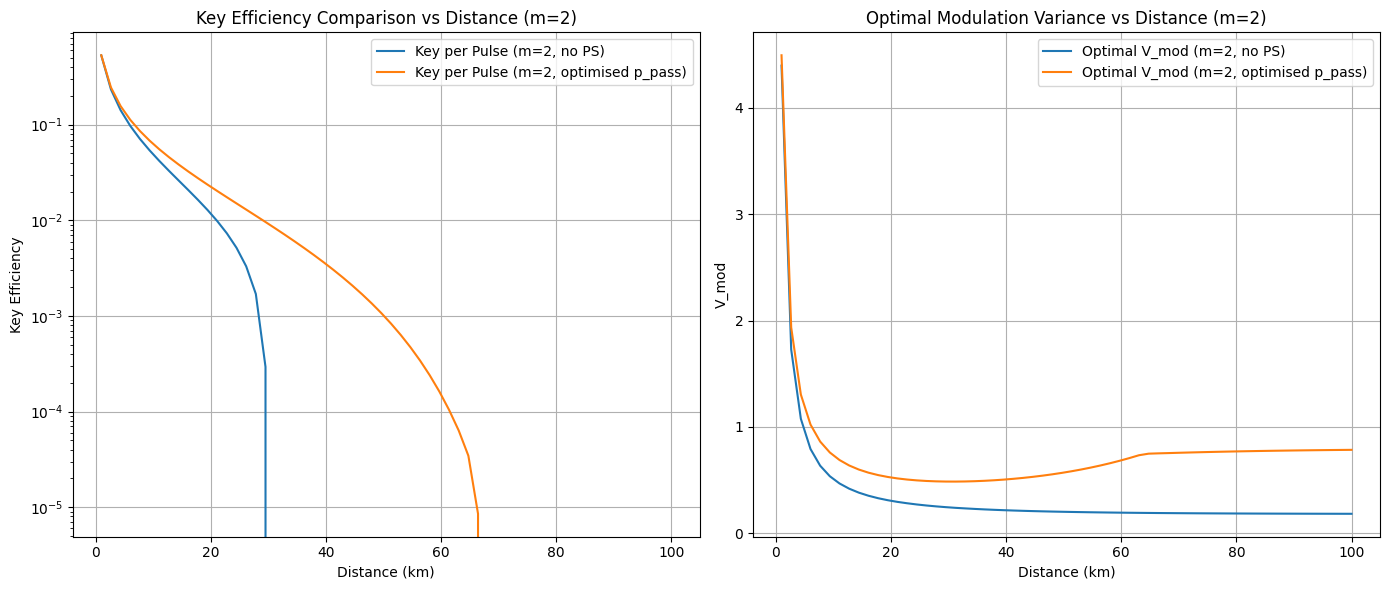

In [9]:
key_per_pulse_no_ps_m2 = []
devetak_winters_no_ps_m2 = []
optimal_v_mods_no_ps_m2 = []
devetak_winter_no_ps_m2 = []

def evaluate_no_ps_metrics_m2(v_mod_candidate: float, transmittance: float):
    gbsr_instance = GBSR(2, float(v_mod_candidate), transmittance, excess_noise)
    tau_arr = gbsr_instance.build_equiprobable_tau()
    g_arr = gbsr_instance.generate_g_arr_from_p_pass(1.0, tau_arr)
    metrics = gbsr_instance.evaluate_quantised_maximum_key_efficiency(tau_arr, g_arr)
    return dict(metrics), gbsr_instance

for distance in tqdm(distances, desc="Optimising V_mod (m=2, no postselection)"):
    transmittance = fibre_transmittance(distance)

    def negative_key_no_ps(v_mod_candidate: float) -> float:
        v_mod_checked = float(np.clip(v_mod_candidate, *v_mod_bounds))
        try:
            metrics_candidate, _ = evaluate_no_ps_metrics_m2(v_mod_checked, transmittance)
        except Exception:
            return np.inf
        return -metrics_candidate["key_per_pulse"]

    optimisation_result = minimize_scalar(
        negative_key_no_ps,
        bounds=v_mod_bounds,
        method="bounded",
        options={"xatol": 1e-3},
    )

    if not optimisation_result.success or not np.isfinite(optimisation_result.fun):
        candidate_v_mods = np.linspace(v_mod_bounds[0], v_mod_bounds[1], 50)
        best_value = np.inf
        best_v_mod = None
        for v_candidate in candidate_v_mods:
            value = negative_key_no_ps(v_candidate)
            if value < best_value:
                best_value = value
                best_v_mod = v_candidate
        if best_v_mod is None:
            raise RuntimeError(f"Failed to optimise V_mod for distance {distance:.2f} km with p_pass = 1 (m=2)")
    else:
        best_v_mod = optimisation_result.x

    best_v_mod = float(np.clip(best_v_mod, *v_mod_bounds))
    best_metrics, best_gbsr = evaluate_no_ps_metrics_m2(best_v_mod, transmittance)

    key_per_pulse_no_ps_m2.append(best_metrics["key_per_pulse"])
    devetak_winters_no_ps_m2.append(best_gbsr.continuous_devetak_winter)
    optimal_v_mods_no_ps_m2.append(best_v_mod)
    devetak_winter_no_ps_m2.append(best_gbsr.continuous_devetak_winter)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(distances, key_per_pulse_no_ps_m2, label="Key per Pulse (m=2, no PS)")
axes[0].plot(distances, key_per_pulse_m2, label="Key per Pulse (m=2, optimised p_pass)")
#axes[0].plot(distances, devetak_winter_no_ps_m2, label="Devetak-Winter (m=2, no PS)")
#axes[0].plot(distances, devetak_winters_m2, label="Devetak-Winter (m=2, optimised p_pass)")
axes[0].set_xlabel("Distance (km)")
axes[0].set_ylabel("Key Efficiency")
axes[0].set_title("Key Efficiency Comparison vs Distance (m=2)")
axes[0].set_yscale("log")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(distances, optimal_v_mods_no_ps_m2, label="Optimal V_mod (m=2, no PS)")
axes[1].plot(distances, optimal_v_mods_m2, label="Optimal V_mod (m=2, optimised p_pass)")
axes[1].set_xlabel("Distance (km)")
axes[1].set_ylabel("V_mod")
axes[1].set_title("Optimal Modulation Variance vs Distance (m=2)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Comparing $m=1$ and $m=2$ Results

Next, we plot the results for $m=1$ and $m=2$ on the same axes for comparison. Dashed lines indicate no postselection ($p_\text{pass} = 1$), while solid lines indicate optimised $p_\text{pass}$.

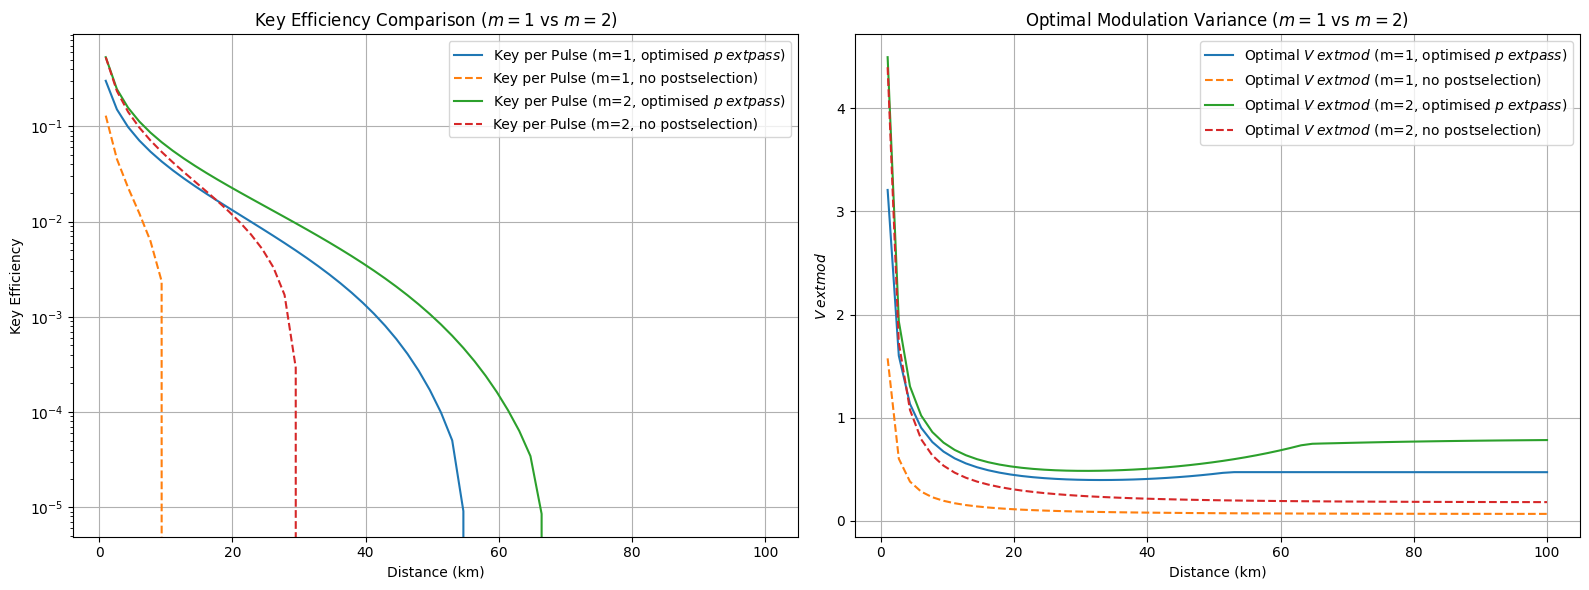

In [10]:
# Plot the results for $m=1$ and $m=2$ on the same axes for comparison.
# Dashed lines indicate no postselection ($p_\text{pass} = 1$), while solid lines indicate optimised $p_\text{pass}$.

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left subplot: Key per Pulse comparison
axes[0].plot(distances, key_per_pulse_m1, label="Key per Pulse (m=1, optimised $p_\text{pass}$)", linestyle="-")
axes[0].plot(distances, key_per_pulse_no_ps_m1, label="Key per Pulse (m=1, no postselection)", linestyle="--")
axes[0].plot(distances, key_per_pulse_m2, label="Key per Pulse (m=2, optimised $p_\text{pass}$)", linestyle="-")
axes[0].plot(distances, key_per_pulse_no_ps_m2, label="Key per Pulse (m=2, no postselection)", linestyle="--")
axes[0].set_xlabel("Distance (km)")
axes[0].set_ylabel("Key Efficiency")
axes[0].set_title("Key Efficiency Comparison ($m=1$ vs $m=2$)")
axes[0].set_yscale("log")
axes[0].legend()
axes[0].grid(True)

# Right subplot: Optimal Modulation Variance comparison
axes[1].plot(distances, optimal_v_mods_m1, label="Optimal $V_\text{mod}$ (m=1, optimised $p_\text{pass}$)", linestyle="-")
axes[1].plot(distances, optimal_v_mods_no_ps_m1, label="Optimal $V_\text{mod}$ (m=1, no postselection)", linestyle="--")
axes[1].plot(distances, optimal_v_mods_m2, label="Optimal $V_\text{mod}$ (m=2, optimised $p_\text{pass}$)", linestyle="-")
axes[1].plot(distances, optimal_v_mods_no_ps_m2, label="Optimal $V_\text{mod}$ (m=2, no postselection)", linestyle="--")
axes[1].set_xlabel("Distance (km)")
axes[1].set_ylabel("$V_\text{mod}$")
axes[1].set_title("Optimal Modulation Variance ($m=1$ vs $m=2$)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## m = 3

Next, we explore the $m=3$ case. We keep the same assumptions as for $m=2$, i.e. equiprobable intervals. Therefore, we only need to optimise $V_\text{mod}$ and $p_\text{pass}$ once again.

Optimising per distance (m=3):   0%|          | 0/60 [00:00<?, ?it/s]

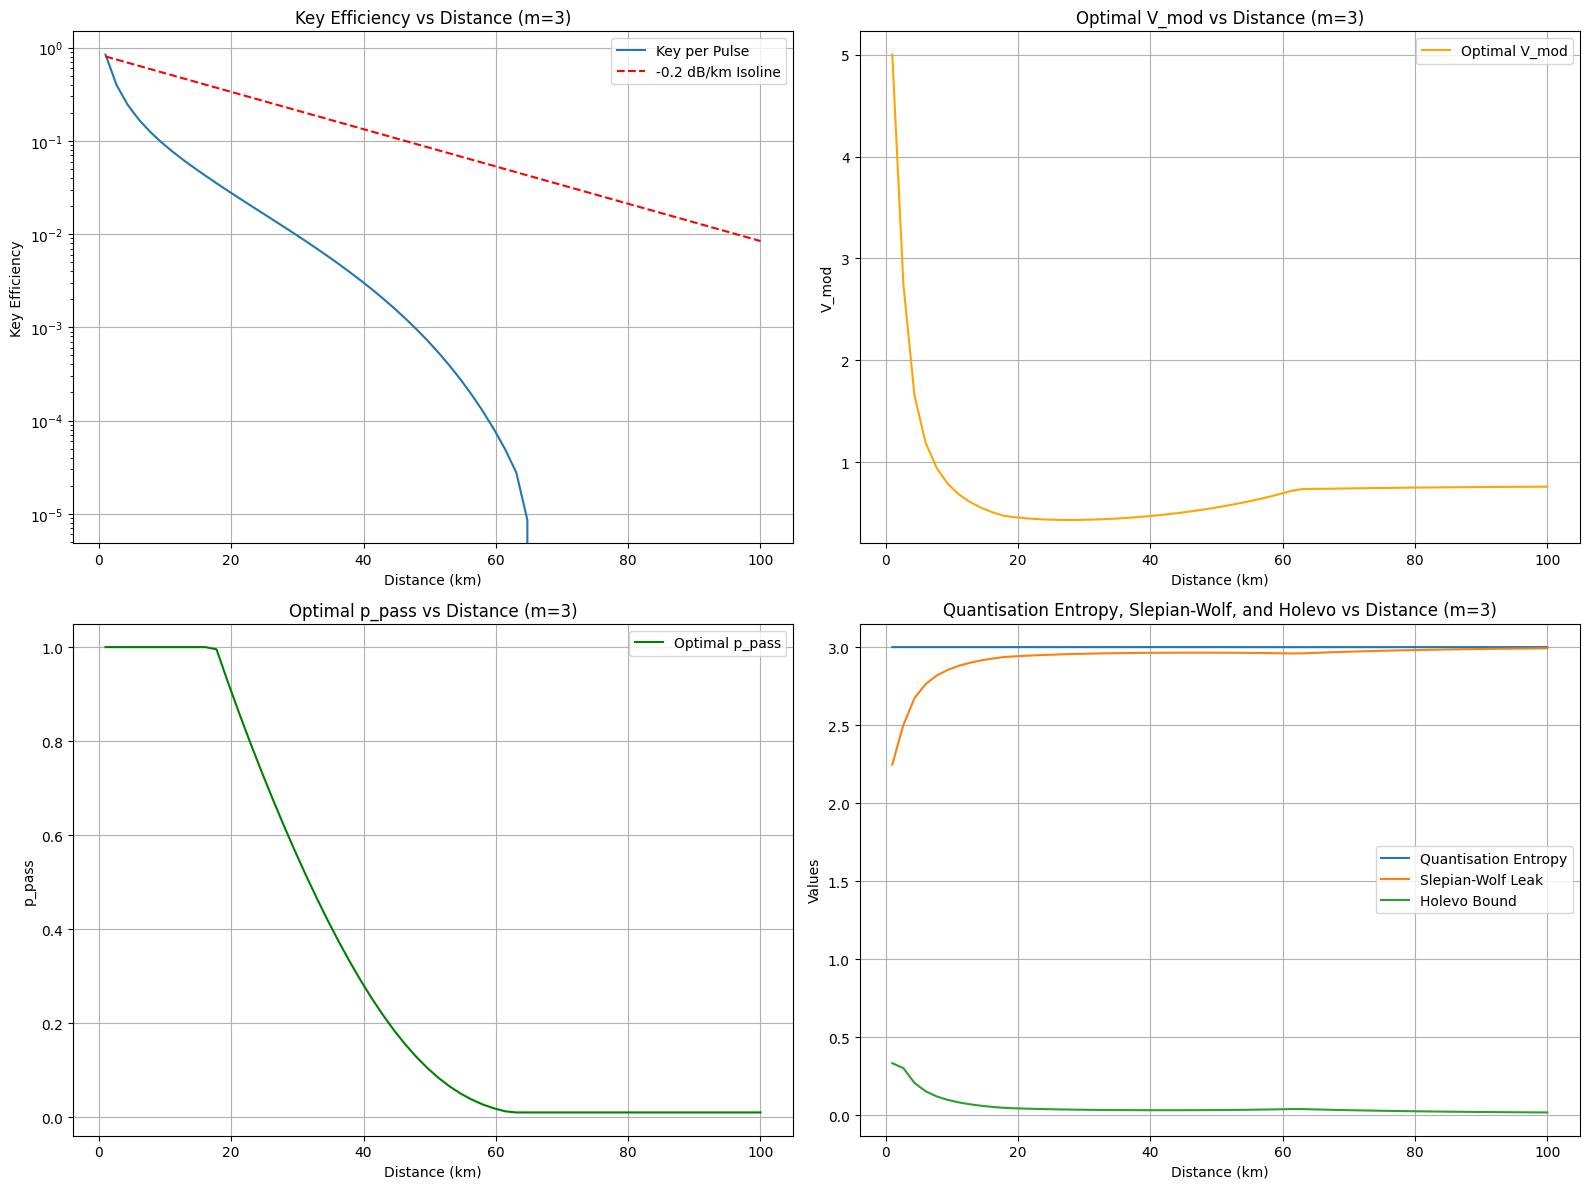

In [11]:
key_per_pulse_m3 = []
key_per_accepted_m3 = []
quantisation_entropies_m3 = []
slepian_wolf_leaks_m3 = []
holevo_bounds_m3 = []
mutual_informations_m3 = []
devetak_winters_m3 = []
optimal_v_mods_m3 = []
optimal_p_passes_m3 = []
optimal_metrics_m3 = []

initial_guess_m3 = np.array([np.mean(v_mod_bounds), 0.8])
bounds_m3 = [v_mod_bounds, p_pass_bounds]

for distance in tqdm(distances, desc="Optimising per distance (m=3)"):
    transmittance = fibre_transmittance(distance)

    def evaluate_metrics_m3(v_mod_candidate: float, p_pass_candidate: float):
        gbsr_instance = GBSR(3, float(v_mod_candidate), transmittance, excess_noise)
        tau_arr = gbsr_instance.build_equiprobable_tau()
        g_arr = gbsr_instance.generate_g_arr_from_p_pass(float(p_pass_candidate), tau_arr)
        metrics = gbsr_instance.evaluate_quantised_maximum_key_efficiency(tau_arr, g_arr)
        return dict(metrics), gbsr_instance

    def negative_key_per_pulse(params):
        v_mod_candidate, p_pass_candidate = params
        v_mod_checked = float(np.clip(v_mod_candidate, *v_mod_bounds))
        p_pass_checked = float(np.clip(p_pass_candidate, *p_pass_bounds))
        try:
            metrics_candidate, _ = evaluate_metrics_m3(v_mod_checked, p_pass_checked)
        except Exception:
            return np.inf
        return -metrics_candidate["key_per_pulse"]

    optimisation_result = minimize(
        negative_key_per_pulse,
        x0=initial_guess_m3,
        bounds=bounds_m3,
        method="Powell",
    )

    if not optimisation_result.success or not np.isfinite(optimisation_result.fun):
        grid_v_mod = np.linspace(v_mod_bounds[0], v_mod_bounds[1], 25)
        grid_p_pass = np.linspace(p_pass_bounds[0], p_pass_bounds[1], 25)
        best_value = np.inf
        best_pair = None
        for v_candidate in grid_v_mod:
            for p_candidate in grid_p_pass:
                value = negative_key_per_pulse((v_candidate, p_candidate))
                if value < best_value:
                    best_value = value
                    best_pair = (v_candidate, p_candidate)
        if best_pair is None:
            raise RuntimeError(f"Failed to find feasible parameters at distance {distance:.2f} km for m=3")
        best_v_mod, best_p_pass = best_pair
    else:
        best_v_mod, best_p_pass = optimisation_result.x

    best_v_mod = float(np.clip(best_v_mod, *v_mod_bounds))
    best_p_pass = float(np.clip(best_p_pass, *p_pass_bounds))
    best_metrics, best_gbsr_instance = evaluate_metrics_m3(best_v_mod, best_p_pass)

    key_per_pulse_m3.append(best_metrics["key_per_pulse"])
    key_per_accepted_m3.append(best_metrics["key_per_accepted_symbol"])
    quantisation_entropies_m3.append(best_metrics["H_Tx_acc"])
    slepian_wolf_leaks_m3.append(best_metrics["H_Tx_given_Ty"])
    holevo_bounds_m3.append(best_metrics["holevo_bound"])
    mutual_informations_m3.append(best_metrics["I_symbol"])
    devetak_winters_m3.append(best_gbsr_instance.continuous_devetak_winter)
    optimal_v_mods_m3.append(best_v_mod)
    optimal_p_passes_m3.append(best_p_pass)

    optimal_metrics_m3.append(best_metrics)
    initial_guess_m3 = np.array([best_v_mod, best_p_pass])

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].plot(distances, key_per_pulse_m3, label="Key per Pulse")
# axes[0, 0].plot(distances, devetak_winters_m3, label="Devetak-Winter")
isoline_m3 = key_per_pulse_m3[0] * 10 ** (-0.2 * distances / 10)
axes[0, 0].plot(distances, isoline_m3, label="-0.2 dB/km Isoline", linestyle="--", color="red")
axes[0, 0].set_xlabel("Distance (km)")
axes[0, 0].set_ylabel("Key Efficiency")
axes[0, 0].set_title("Key Efficiency vs Distance (m=3)")
axes[0, 0].set_yscale("log")
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].plot(distances, optimal_v_mods_m3, label="Optimal V_mod", color="orange")
axes[0, 1].set_xlabel("Distance (km)")
axes[0, 1].set_ylabel("V_mod")
axes[0, 1].set_title("Optimal V_mod vs Distance (m=3)")
axes[0, 1].legend()
axes[0, 1].grid(True)

axes[1, 0].plot(distances, optimal_p_passes_m3, label="Optimal p_pass", color="green")
axes[1, 0].set_xlabel("Distance (km)")
axes[1, 0].set_ylabel("p_pass")
axes[1, 0].set_title("Optimal p_pass vs Distance (m=3)")
axes[1, 0].legend()
axes[1, 0].grid(True)

axes[1, 1].plot(distances, quantisation_entropies_m3, label="Quantisation Entropy")
axes[1, 1].plot(distances, slepian_wolf_leaks_m3, label="Slepian-Wolf Leak")
axes[1, 1].plot(distances, holevo_bounds_m3, label="Holevo Bound")
axes[1, 1].set_xlabel("Distance (km)")
axes[1, 1].set_ylabel("Values")
axes[1, 1].set_title("Quantisation Entropy, Slepian-Wolf, and Holevo vs Distance (m=3)")
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

Next, we also do the usual optimisation for the no postselection case ($p_\text{pass} = 1$).

Optimising V_mod (m=3, no postselection):   0%|          | 0/60 [00:00<?, ?it/s]

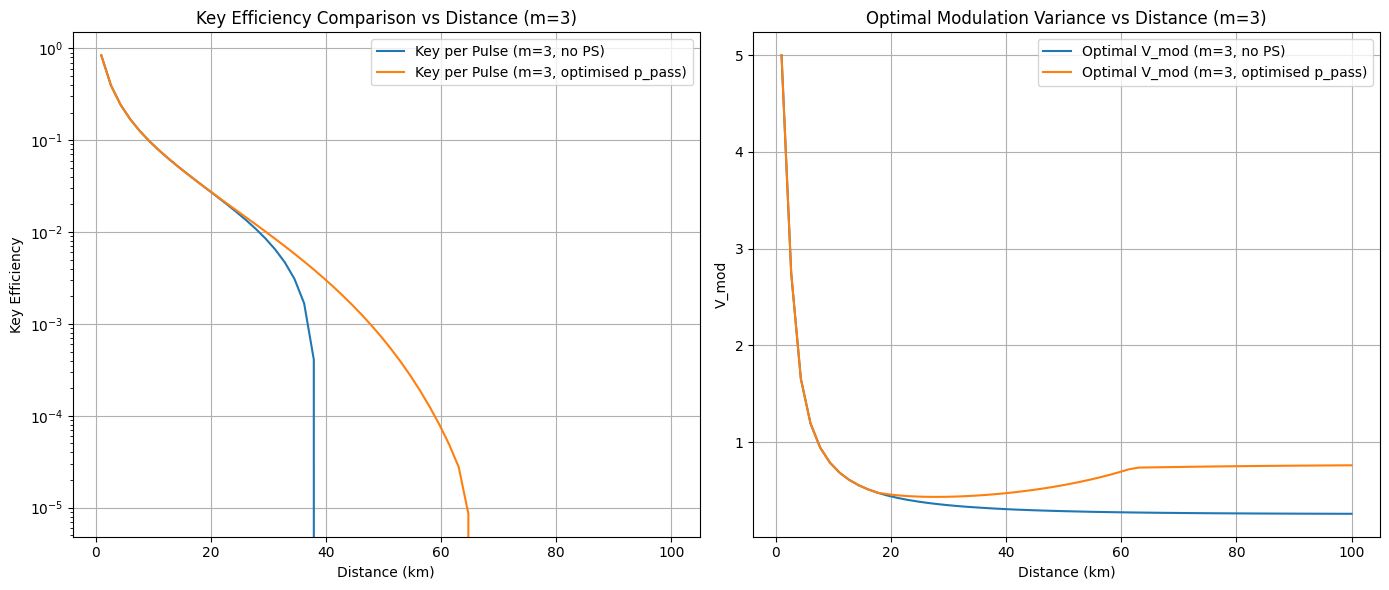

In [12]:
key_per_pulse_no_ps_m3 = []
devetak_winters_no_ps_m3 = []
optimal_v_mods_no_ps_m3 = []
devetak_winter_no_ps_m3 = []

def evaluate_no_ps_metrics_m3(v_mod_candidate: float, transmittance: float):
    gbsr_instance = GBSR(3, float(v_mod_candidate), transmittance, excess_noise)
    tau_arr = gbsr_instance.build_equiprobable_tau()
    g_arr = gbsr_instance.generate_g_arr_from_p_pass(1.0, tau_arr)
    metrics = gbsr_instance.evaluate_quantised_maximum_key_efficiency(tau_arr, g_arr)
    return dict(metrics), gbsr_instance

for distance in tqdm(distances, desc="Optimising V_mod (m=3, no postselection)"):
    transmittance = fibre_transmittance(distance)

    def negative_key_no_ps(v_mod_candidate: float) -> float:
        v_mod_checked = float(np.clip(v_mod_candidate, *v_mod_bounds))
        try:
            metrics_candidate, _ = evaluate_no_ps_metrics_m3(v_mod_checked, transmittance)
        except Exception:
            return np.inf
        return -metrics_candidate["key_per_pulse"]

    optimisation_result = minimize_scalar(
        negative_key_no_ps,
        bounds=v_mod_bounds,
        method="bounded",
        options={"xatol": 1e-3},
    )

    if not optimisation_result.success or not np.isfinite(optimisation_result.fun):
        candidate_v_mods = np.linspace(v_mod_bounds[0], v_mod_bounds[1], 50)
        best_value = np.inf
        best_v_mod = None
        for v_candidate in candidate_v_mods:
            value = negative_key_no_ps(v_candidate)
            if value < best_value:
                best_value = value
                best_v_mod = v_candidate
        if best_v_mod is None:
            raise RuntimeError(f"Failed to optimise V_mod for distance {distance:.2f} km with p_pass = 1 (m=3)")
    else:
        best_v_mod = optimisation_result.x

    best_v_mod = float(np.clip(best_v_mod, *v_mod_bounds))
    best_metrics, best_gbsr = evaluate_no_ps_metrics_m3(best_v_mod, transmittance)

    key_per_pulse_no_ps_m3.append(best_metrics["key_per_pulse"])
    devetak_winters_no_ps_m3.append(best_gbsr.continuous_devetak_winter)
    optimal_v_mods_no_ps_m3.append(best_v_mod)
    devetak_winter_no_ps_m3.append(best_gbsr.continuous_devetak_winter)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(distances, key_per_pulse_no_ps_m3, label="Key per Pulse (m=3, no PS)")
axes[0].plot(distances, key_per_pulse_m3, label="Key per Pulse (m=3, optimised p_pass)")
axes[0].set_xlabel("Distance (km)")
axes[0].set_ylabel("Key Efficiency")
axes[0].set_title("Key Efficiency Comparison vs Distance (m=3)")
axes[0].set_yscale("log")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(distances, optimal_v_mods_no_ps_m3, label="Optimal V_mod (m=3, no PS)")
axes[1].plot(distances, optimal_v_mods_m3, label="Optimal V_mod (m=3, optimised p_pass)")
axes[1].set_xlabel("Distance (km)")
axes[1].set_ylabel("V_mod")
axes[1].set_title("Optimal Modulation Variance vs Distance (m=3)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Comparing $m = 1, 2, 3$ Results

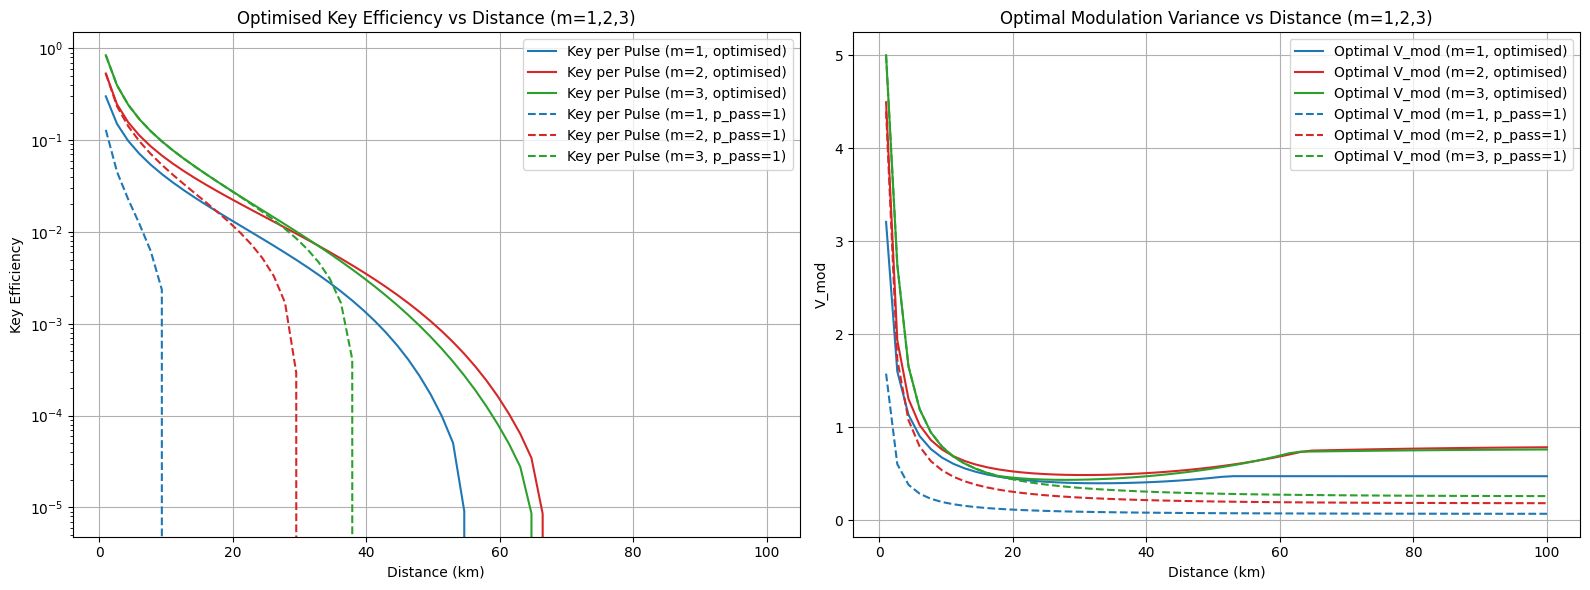

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

color_map = {"m1": "tab:blue", "m2": "tab:red", "m3": "tab:green"}
label_map = {"m1": "m=1", "m2": "m=2", "m3": "m=3"}

axes[0].plot(distances, key_per_pulse_m1, color=color_map["m1"], linestyle="-", label="Key per Pulse (m=1, optimised)")
axes[0].plot(distances, key_per_pulse_m2, color=color_map["m2"], linestyle="-", label="Key per Pulse (m=2, optimised)")
axes[0].plot(distances, key_per_pulse_m3, color=color_map["m3"], linestyle="-", label="Key per Pulse (m=3, optimised)")
axes[0].plot(distances, key_per_pulse_no_ps_m1, color=color_map["m1"], linestyle="--", label="Key per Pulse (m=1, p_pass=1)")
axes[0].plot(distances, key_per_pulse_no_ps_m2, color=color_map["m2"], linestyle="--", label="Key per Pulse (m=2, p_pass=1)")
axes[0].plot(distances, key_per_pulse_no_ps_m3, color=color_map["m3"], linestyle="--", label="Key per Pulse (m=3, p_pass=1)")
axes[0].set_xlabel("Distance (km)")
axes[0].set_ylabel("Key Efficiency")
axes[0].set_title("Optimised Key Efficiency vs Distance (m=1,2,3)")
axes[0].set_yscale("log")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(distances, optimal_v_mods_m1, color=color_map["m1"], linestyle="-", label="Optimal V_mod (m=1, optimised)")
axes[1].plot(distances, optimal_v_mods_m2, color=color_map["m2"], linestyle="-", label="Optimal V_mod (m=2, optimised)")
axes[1].plot(distances, optimal_v_mods_m3, color=color_map["m3"], linestyle="-", label="Optimal V_mod (m=3, optimised)")
axes[1].plot(distances, optimal_v_mods_no_ps_m1, color=color_map["m1"], linestyle="--", label="Optimal V_mod (m=1, p_pass=1)")
axes[1].plot(distances, optimal_v_mods_no_ps_m2, color=color_map["m2"], linestyle="--", label="Optimal V_mod (m=2, p_pass=1)")
axes[1].plot(distances, optimal_v_mods_no_ps_m3, color=color_map["m3"], linestyle="--", label="Optimal V_mod (m=3, p_pass=1)")
axes[1].set_xlabel("Distance (km)")
axes[1].set_ylabel("V_mod")
axes[1].set_title("Optimal Modulation Variance vs Distance (m=1,2,3)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Practical Key Rates

So, now, we are trying to explore the practical key rates achievable for $m=1, 2, 3$.

## $m = 1$

Optimising practical m=1:   0%|          | 0/60 [00:00<?, ?it/s]

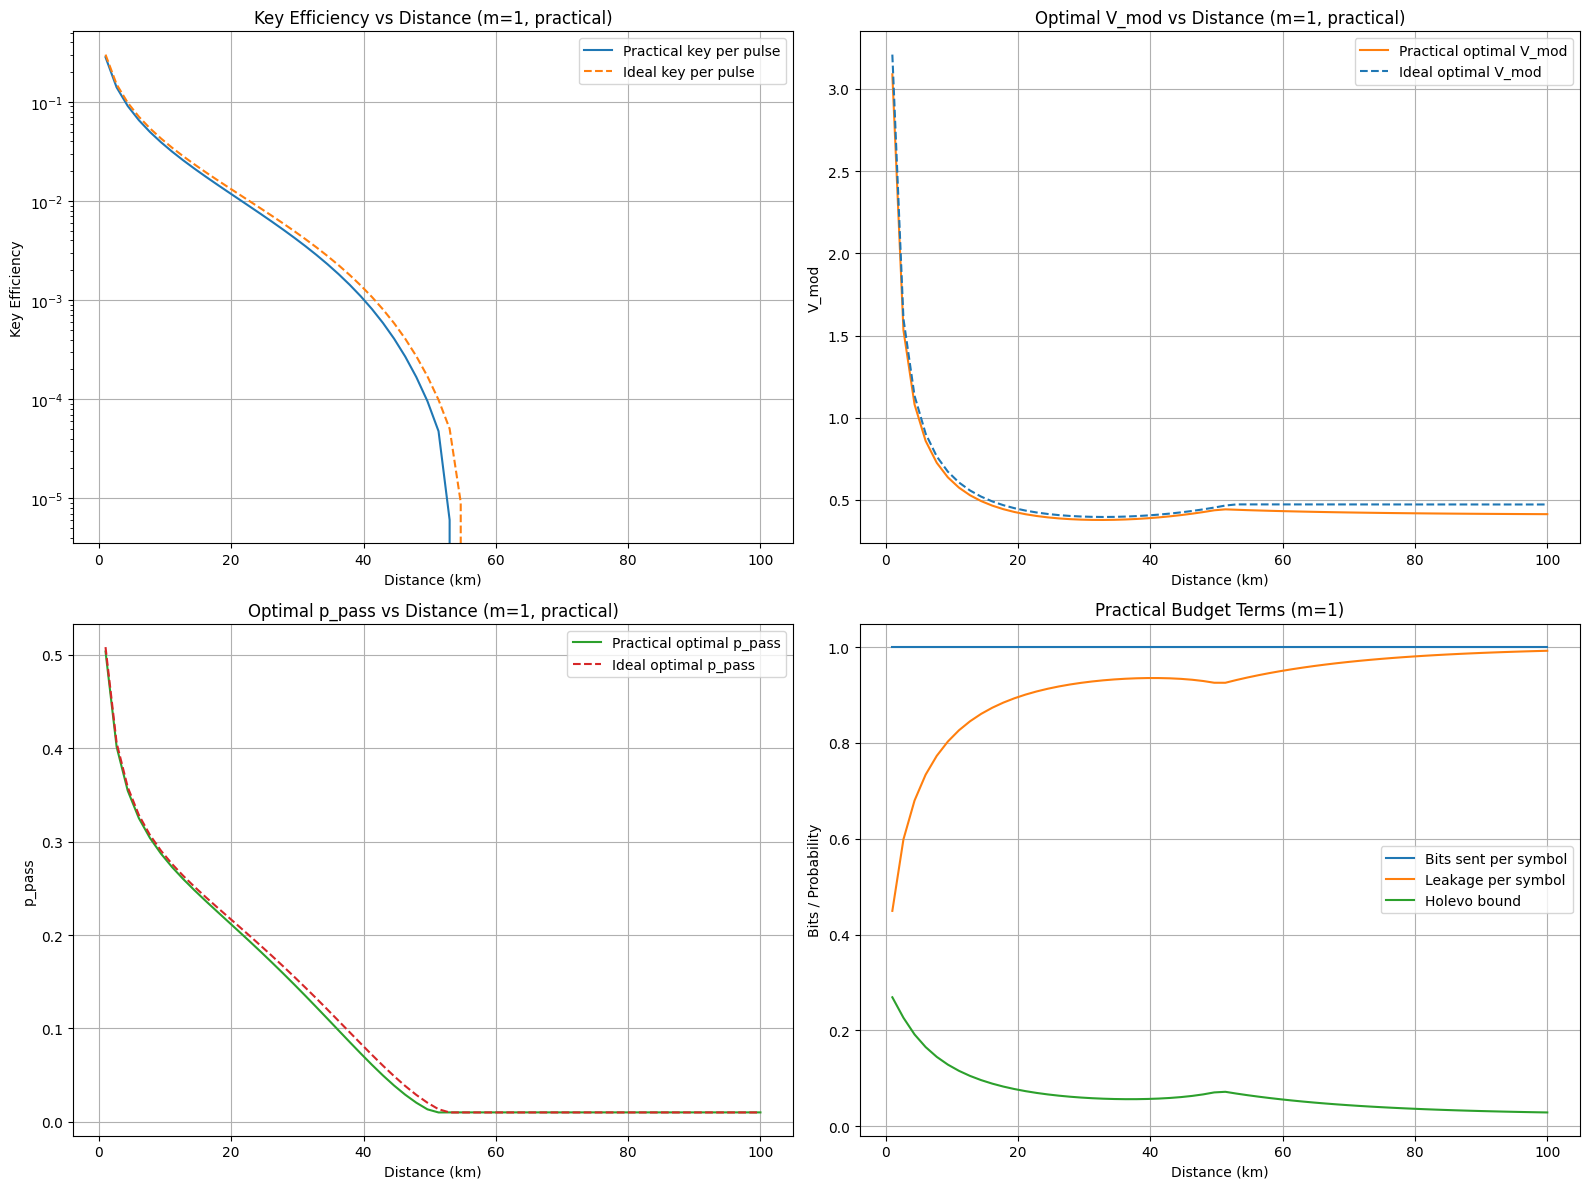

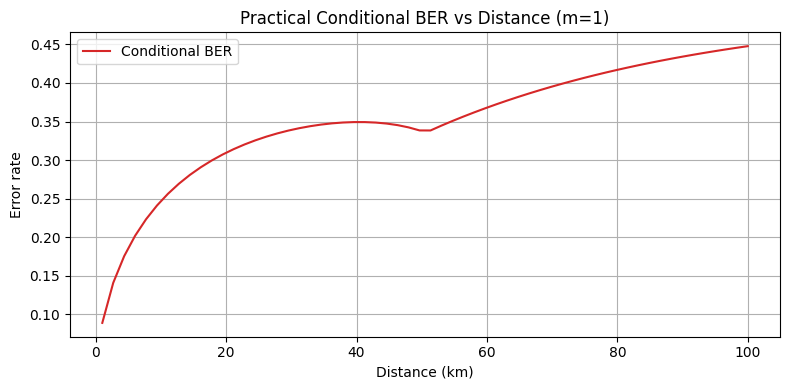

In [15]:
practical_bits_model = 'H_Tx'

practical_key_per_pulse_m1 = []
practical_key_per_accepted_m1 = []
practical_error_rates_m1 = []
practical_leakage_m1 = []
practical_holevo_bounds_m1 = []
practical_opt_v_mods_m1 = []
practical_opt_p_passes_m1 = []
practical_bits_sent_m1 = []
practical_metrics_m1 = []

bounds_practical = Bounds(
    [v_mod_bounds[0], p_pass_bounds[0]],
    [v_mod_bounds[1], p_pass_bounds[1]],
)
initial_guess_practical = np.array([np.mean(v_mod_bounds), 0.8])

for distance in tqdm(distances, desc='Optimising practical m=1'):
    transmittance = fibre_transmittance(distance)

    def evaluate_practical_metrics(v_mod_candidate: float, p_pass_candidate: float):
        gbsr_instance = GBSR(
            1,
            float(v_mod_candidate),
            transmittance,
            excess_noise,
            practical_coding_efficiency=practical_coding_efficiency,
        )
        tau_arr = gbsr_instance.build_equiprobable_tau()
        g_arr = gbsr_instance.generate_g_arr_from_p_pass(float(p_pass_candidate), tau_arr)
        metrics = gbsr_instance.evaluate_practical_key_efficiency(
            tau_arr,
            g_arr,
            bits_model=practical_bits_model,
            include_delta_qct=False,
            bit_assignment='Gray',
        )
        return dict(metrics), gbsr_instance

    def negative_practical(params):
        v_mod_candidate, p_pass_candidate = params
        v_mod_checked = float(np.clip(v_mod_candidate, *v_mod_bounds))
        p_pass_checked = float(np.clip(p_pass_candidate, *p_pass_bounds))
        try:
            metrics_candidate, _ = evaluate_practical_metrics(v_mod_checked, p_pass_checked)
        except Exception:
            return np.inf
        return -metrics_candidate['key_per_pulse']

    optimisation_result = minimize(
        negative_practical,
        x0=initial_guess_practical,
        bounds=bounds_practical,
        method='Powell',
    )

    if not optimisation_result.success or not np.isfinite(optimisation_result.fun):
        grid_v_mod = np.linspace(v_mod_bounds[0], v_mod_bounds[1], 25)
        grid_p_pass = np.linspace(p_pass_bounds[0], p_pass_bounds[1], 25)
        best_value = np.inf
        best_pair = None
        for v_candidate in grid_v_mod:
            for p_candidate in grid_p_pass:
                value = negative_practical((v_candidate, p_candidate))
                if value < best_value:
                    best_value = value
                    best_pair = (v_candidate, p_candidate)
        if best_pair is None:
            raise RuntimeError(f'Failed to find feasible parameters at distance {distance:.2f} km for practical m=1')
        best_v_mod, best_p_pass = best_pair
    else:
        best_v_mod, best_p_pass = optimisation_result.x

    best_v_mod = float(np.clip(best_v_mod, *v_mod_bounds))
    best_p_pass = float(np.clip(best_p_pass, *p_pass_bounds))
    best_metrics, best_gbsr_instance = evaluate_practical_metrics(best_v_mod, best_p_pass)

    practical_key_per_pulse_m1.append(best_metrics['key_per_pulse'])
    practical_key_per_accepted_m1.append(best_metrics['key_per_accepted_symbol'])
    practical_error_rates_m1.append(best_metrics['error_rate'])
    practical_leakage_m1.append(best_metrics['leaked_info_per_symbol'])
    practical_holevo_bounds_m1.append(best_metrics['holevo_bound'])
    practical_opt_v_mods_m1.append(best_v_mod)
    practical_opt_p_passes_m1.append(best_p_pass)
    practical_bits_sent_m1.append(best_metrics['bits_sent_per_symbol'])
    practical_metrics_m1.append(best_metrics)

    initial_guess_practical = np.array([best_v_mod, best_p_pass])

practical_key_per_pulse_m1 = np.array(practical_key_per_pulse_m1)
practical_key_per_accepted_m1 = np.array(practical_key_per_accepted_m1)
practical_error_rates_m1 = np.array(practical_error_rates_m1)
practical_leakage_m1 = np.array(practical_leakage_m1)
practical_holevo_bounds_m1 = np.array(practical_holevo_bounds_m1)
practical_opt_v_mods_m1 = np.array(practical_opt_v_mods_m1)
practical_opt_p_passes_m1 = np.array(practical_opt_p_passes_m1)
practical_bits_sent_m1 = np.array(practical_bits_sent_m1)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].plot(distances, practical_key_per_pulse_m1, label='Practical key per pulse')
if 'key_per_pulse_m1' in globals():
    axes[0, 0].plot(distances, key_per_pulse_m1, linestyle='--', label='Ideal key per pulse')
axes[0, 0].set_xlabel('Distance (km)')
axes[0, 0].set_ylabel('Key Efficiency')
axes[0, 0].set_title('Key Efficiency vs Distance (m=1, practical)')
axes[0, 0].set_yscale('log')
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].plot(distances, practical_opt_v_mods_m1, label='Practical optimal V_mod', color='tab:orange')
if 'optimal_v_mods_m1' in globals():
    axes[0, 1].plot(distances, optimal_v_mods_m1, linestyle='--', label='Ideal optimal V_mod', color='tab:blue')
axes[0, 1].set_xlabel('Distance (km)')
axes[0, 1].set_ylabel('V_mod')
axes[0, 1].set_title('Optimal V_mod vs Distance (m=1, practical)')
axes[0, 1].legend()
axes[0, 1].grid(True)

axes[1, 0].plot(distances, practical_opt_p_passes_m1, label='Practical optimal p_pass', color='tab:green')
if 'optimal_p_passes_m1' in globals():
    axes[1, 0].plot(distances, optimal_p_passes_m1, linestyle='--', label='Ideal optimal p_pass', color='tab:red')
axes[1, 0].set_xlabel('Distance (km)')
axes[1, 0].set_ylabel('p_pass')
axes[1, 0].set_title('Optimal p_pass vs Distance (m=1, practical)')
axes[1, 0].legend()
axes[1, 0].grid(True)

axes[1, 1].plot(distances, practical_bits_sent_m1, label='Bits sent per symbol')
axes[1, 1].plot(distances, practical_leakage_m1, label='Leakage per symbol')
axes[1, 1].plot(distances, practical_holevo_bounds_m1, label='Holevo bound')
axes[1, 1].set_xlabel('Distance (km)')
axes[1, 1].set_ylabel('Bits / Probability')
axes[1, 1].set_title('Practical Budget Terms (m=1)')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(distances, practical_error_rates_m1, color='tab:red', label='Conditional BER')
ax.set_xlabel('Distance (km)')
ax.set_ylabel('Error rate')
ax.set_title('Practical Conditional BER vs Distance (m=1)')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


## $m = 2$

Optimising practical m=2:   0%|          | 0/60 [00:00<?, ?it/s]

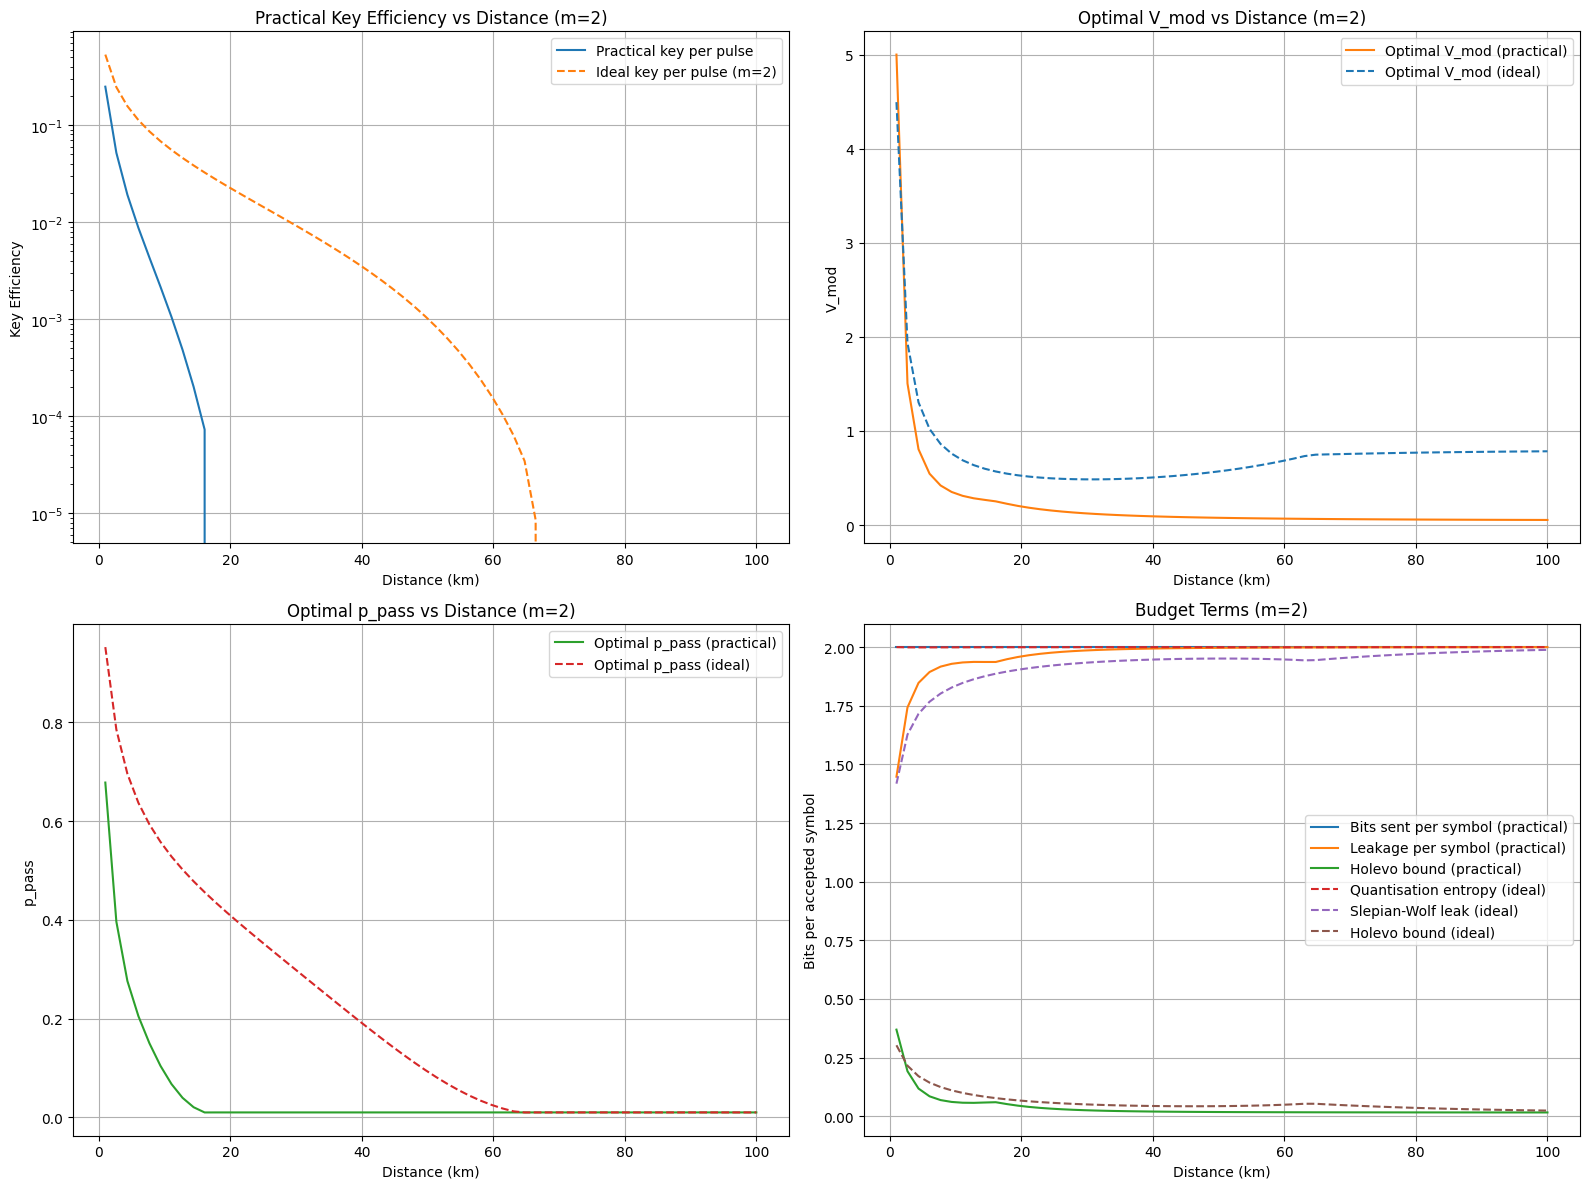

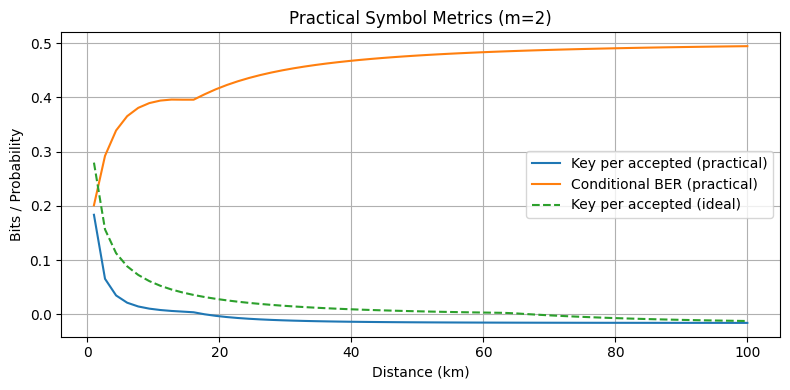

In [16]:
practical_coding_efficiency_m2 = 1.0
practical_bits_model_m2 = 'H_Tx'

practical_key_per_pulse_m2 = []
practical_key_per_accepted_m2 = []
practical_error_rates_m2 = []
practical_leakage_m2 = []
practical_holevo_bounds_m2 = []
practical_bits_sent_m2 = []
practical_opt_v_mods_m2 = []
practical_opt_p_passes_m2 = []
practical_metrics_m2 = []

initial_guess_practical_m2 = np.array([np.mean(v_mod_bounds), 0.8])
bounds_practical_m2 = [v_mod_bounds, p_pass_bounds]

for distance in tqdm(distances, desc='Optimising practical m=2'):
    transmittance = fibre_transmittance(distance)

    def evaluate_practical_metrics_m2(v_mod_candidate: float, p_pass_candidate: float):
        gbsr_instance = GBSR(
            2,
            float(v_mod_candidate),
            transmittance,
            excess_noise,
            practical_coding_efficiency=practical_coding_efficiency_m2,
        )
        tau_arr = gbsr_instance.build_equiprobable_tau()
        g_arr = gbsr_instance.generate_g_arr_from_p_pass(float(p_pass_candidate), tau_arr)
        metrics = gbsr_instance.evaluate_practical_key_efficiency(
            tau_arr,
            g_arr,
            bits_model=practical_bits_model_m2,
            include_delta_qct=False,
            bit_assignment='Gray',
        )
        return dict(metrics), gbsr_instance

    def negative_practical_m2(params):
        v_mod_candidate, p_pass_candidate = params
        v_mod_checked = float(np.clip(v_mod_candidate, *v_mod_bounds))
        p_pass_checked = float(np.clip(p_pass_candidate, *p_pass_bounds))
        try:
            metrics_candidate, _ = evaluate_practical_metrics_m2(v_mod_checked, p_pass_checked)
        except Exception:
            return np.inf
        return -metrics_candidate['key_per_pulse']

    optimisation_result = minimize(
        negative_practical_m2,
        x0=initial_guess_practical_m2,
        bounds=bounds_practical_m2,
        method='Powell',
    )

    if not optimisation_result.success or not np.isfinite(optimisation_result.fun):
        grid_v_mod = np.linspace(v_mod_bounds[0], v_mod_bounds[1], 25)
        grid_p_pass = np.linspace(p_pass_bounds[0], p_pass_bounds[1], 25)
        best_value = np.inf
        best_pair = None
        for v_candidate in grid_v_mod:
            for p_candidate in grid_p_pass:
                value = negative_practical_m2((v_candidate, p_candidate))
                if value < best_value:
                    best_value = value
                    best_pair = (v_candidate, p_candidate)
        if best_pair is None:
            raise RuntimeError(f"Failed to find feasible parameters at distance {distance:.2f} km for practical m=2")
        best_v_mod, best_p_pass = best_pair
    else:
        best_v_mod, best_p_pass = optimisation_result.x

    best_v_mod = float(np.clip(best_v_mod, *v_mod_bounds))
    best_p_pass = float(np.clip(best_p_pass, *p_pass_bounds))
    best_metrics, best_gbsr_instance = evaluate_practical_metrics_m2(best_v_mod, best_p_pass)

    practical_key_per_pulse_m2.append(best_metrics['key_per_pulse'])
    practical_key_per_accepted_m2.append(best_metrics['key_per_accepted_symbol'])
    practical_error_rates_m2.append(best_metrics['error_rate'])
    practical_leakage_m2.append(best_metrics['leaked_info_per_symbol'])
    practical_holevo_bounds_m2.append(best_metrics['holevo_bound'])
    practical_bits_sent_m2.append(best_metrics['bits_sent_per_symbol'])
    practical_opt_v_mods_m2.append(best_v_mod)
    practical_opt_p_passes_m2.append(best_metrics['p_pass'])
    practical_metrics_m2.append(best_metrics)

    initial_guess_practical_m2 = np.array([best_v_mod, best_p_pass])

practical_key_per_pulse_m2 = np.array(practical_key_per_pulse_m2)
practical_key_per_accepted_m2 = np.array(practical_key_per_accepted_m2)
practical_error_rates_m2 = np.array(practical_error_rates_m2)
practical_leakage_m2 = np.array(practical_leakage_m2)
practical_holevo_bounds_m2 = np.array(practical_holevo_bounds_m2)
practical_bits_sent_m2 = np.array(practical_bits_sent_m2)
practical_opt_v_mods_m2 = np.array(practical_opt_v_mods_m2)
practical_opt_p_passes_m2 = np.array(practical_opt_p_passes_m2)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].plot(distances, practical_key_per_pulse_m2, label='Practical key per pulse')
if 'key_per_pulse_m2' in globals():
    axes[0, 0].plot(distances, np.asarray(key_per_pulse_m2), linestyle='--', label='Ideal key per pulse (m=2)')
axes[0, 0].set_xlabel('Distance (km)')
axes[0, 0].set_ylabel('Key Efficiency')
axes[0, 0].set_title('Practical Key Efficiency vs Distance (m=2)')
axes[0, 0].set_yscale('log')
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].plot(distances, practical_opt_v_mods_m2, color='tab:orange', label='Optimal V_mod (practical)')
if 'optimal_v_mods_m2' in globals():
    axes[0, 1].plot(distances, np.asarray(optimal_v_mods_m2), linestyle='--', color='tab:blue', label='Optimal V_mod (ideal)')
axes[0, 1].set_xlabel('Distance (km)')
axes[0, 1].set_ylabel('V_mod')
axes[0, 1].set_title('Optimal V_mod vs Distance (m=2)')
axes[0, 1].legend()
axes[0, 1].grid(True)

axes[1, 0].plot(distances, practical_opt_p_passes_m2, color='tab:green', label='Optimal p_pass (practical)')
if 'optimal_p_passes_m2' in globals():
    axes[1, 0].plot(distances, np.asarray(optimal_p_passes_m2), linestyle='--', color='tab:red', label='Optimal p_pass (ideal)')
axes[1, 0].set_xlabel('Distance (km)')
axes[1, 0].set_ylabel('p_pass')
axes[1, 0].set_title('Optimal p_pass vs Distance (m=2)')
axes[1, 0].legend()
axes[1, 0].grid(True)

axes[1, 1].plot(distances, practical_bits_sent_m2, label='Bits sent per symbol (practical)')
axes[1, 1].plot(distances, practical_leakage_m2, label='Leakage per symbol (practical)')
axes[1, 1].plot(distances, practical_holevo_bounds_m2, label='Holevo bound (practical)')
if 'quantisation_entropies_m2' in globals():
    axes[1, 1].plot(distances, np.asarray(quantisation_entropies_m2), linestyle='--', label='Quantisation entropy (ideal)')
if 'slepian_wolf_leaks_m2' in globals():
    axes[1, 1].plot(distances, np.asarray(slepian_wolf_leaks_m2), linestyle='--', label='Slepian-Wolf leak (ideal)')
if 'holevo_bounds_m2' in globals():
    axes[1, 1].plot(distances, np.asarray(holevo_bounds_m2), linestyle='--', label='Holevo bound (ideal)')
axes[1, 1].set_xlabel('Distance (km)')
axes[1, 1].set_ylabel('Bits per accepted symbol')
axes[1, 1].set_title('Budget Terms (m=2)')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(distances, practical_key_per_accepted_m2, label='Key per accepted (practical)')
ax.plot(distances, practical_error_rates_m2, label='Conditional BER (practical)')
if 'key_per_accepted_m2' in globals():
    ax.plot(distances, np.asarray(key_per_accepted_m2), linestyle='--', label='Key per accepted (ideal)')
ax.set_xlabel('Distance (km)')
ax.set_ylabel('Bits / Probability')
ax.set_title('Practical Symbol Metrics (m=2)')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


## $m = 3$

Optimising practical m=3:   0%|          | 0/60 [00:00<?, ?it/s]

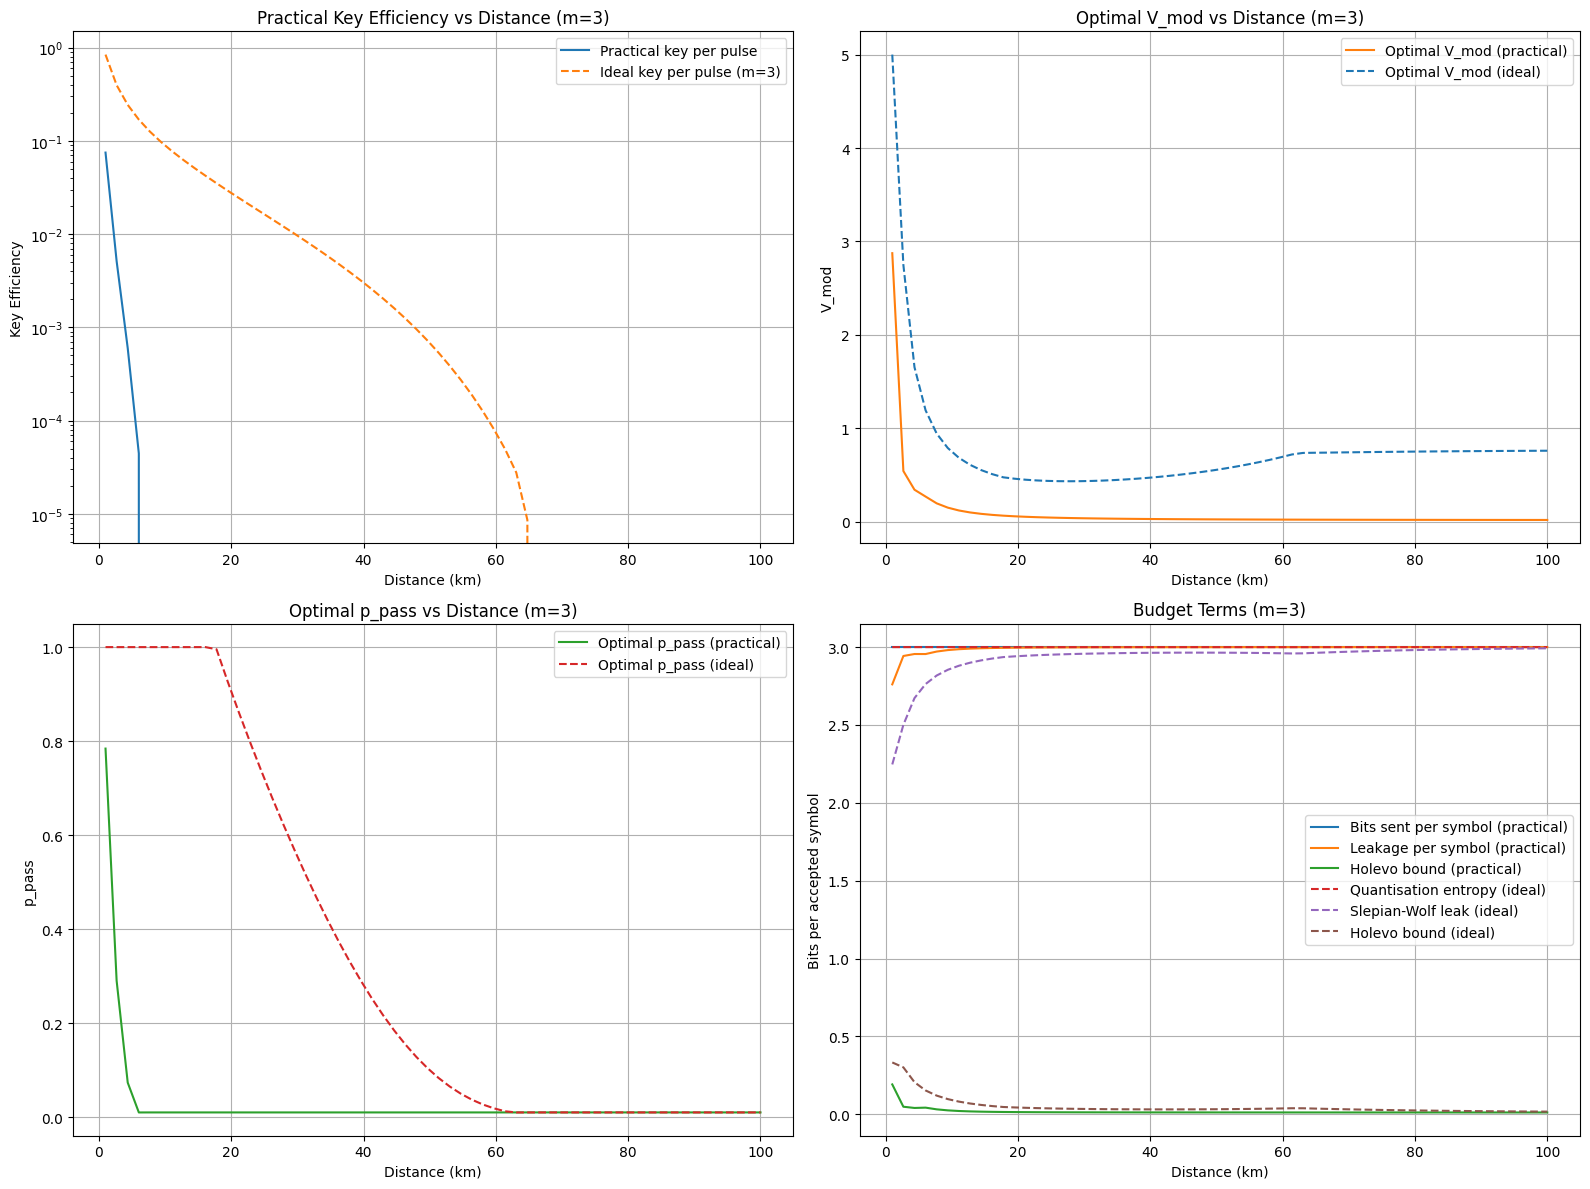

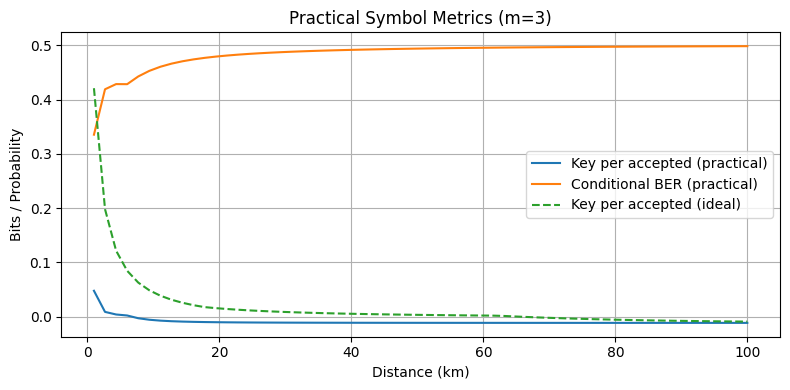

In [17]:
practical_coding_efficiency_m3 = 1.0
practical_bits_model_m3 = 'H_Tx'

practical_key_per_pulse_m3 = []
practical_key_per_accepted_m3 = []
practical_error_rates_m3 = []
practical_leakage_m3 = []
practical_holevo_bounds_m3 = []
practical_bits_sent_m3 = []
practical_opt_v_mods_m3 = []
practical_opt_p_passes_m3 = []
practical_metrics_m3 = []

initial_guess_practical_m3 = np.array([np.mean(v_mod_bounds), 0.8])
bounds_practical_m3 = [v_mod_bounds, p_pass_bounds]

for distance in tqdm(distances, desc='Optimising practical m=3'):
    transmittance = fibre_transmittance(distance)

    def evaluate_practical_metrics_m3(v_mod_candidate: float, p_pass_candidate: float):
        gbsr_instance = GBSR(
            3,
            float(v_mod_candidate),
            transmittance,
            excess_noise,
            practical_coding_efficiency=practical_coding_efficiency_m3,
        )
        tau_arr = gbsr_instance.build_equiprobable_tau()
        g_arr = gbsr_instance.generate_g_arr_from_p_pass(float(p_pass_candidate), tau_arr)
        metrics = gbsr_instance.evaluate_practical_key_efficiency(
            tau_arr,
            g_arr,
            bits_model=practical_bits_model_m3,
            include_delta_qct=False,
            bit_assignment='Gray',
        )
        return dict(metrics), gbsr_instance

    def negative_practical_m3(params):
        v_mod_candidate, p_pass_candidate = params
        v_mod_checked = float(np.clip(v_mod_candidate, *v_mod_bounds))
        p_pass_checked = float(np.clip(p_pass_candidate, *p_pass_bounds))
        try:
            metrics_candidate, _ = evaluate_practical_metrics_m3(v_mod_checked, p_pass_checked)
        except Exception:
            return np.inf
        return -metrics_candidate['key_per_pulse']

    optimisation_result = minimize(
        negative_practical_m3,
        x0=initial_guess_practical_m3,
        bounds=bounds_practical_m3,
        method='Powell',
    )

    if not optimisation_result.success or not np.isfinite(optimisation_result.fun):
        grid_v_mod = np.linspace(v_mod_bounds[0], v_mod_bounds[1], 25)
        grid_p_pass = np.linspace(p_pass_bounds[0], p_pass_bounds[1], 25)
        best_value = np.inf
        best_pair = None
        for v_candidate in grid_v_mod:
            for p_candidate in grid_p_pass:
                value = negative_practical_m3((v_candidate, p_candidate))
                if value < best_value:
                    best_value = value
                    best_pair = (v_candidate, p_candidate)
        if best_pair is None:
            raise RuntimeError(f"Failed to find feasible parameters at distance {distance:.2f} km for practical m=3")
        best_v_mod, best_p_pass = best_pair
    else:
        best_v_mod, best_p_pass = optimisation_result.x

    best_v_mod = float(np.clip(best_v_mod, *v_mod_bounds))
    best_p_pass = float(np.clip(best_p_pass, *p_pass_bounds))
    best_metrics, best_gbsr_instance = evaluate_practical_metrics_m3(best_v_mod, best_p_pass)

    practical_key_per_pulse_m3.append(best_metrics['key_per_pulse'])
    practical_key_per_accepted_m3.append(best_metrics['key_per_accepted_symbol'])
    practical_error_rates_m3.append(best_metrics['error_rate'])
    practical_leakage_m3.append(best_metrics['leaked_info_per_symbol'])
    practical_holevo_bounds_m3.append(best_metrics['holevo_bound'])
    practical_bits_sent_m3.append(best_metrics['bits_sent_per_symbol'])
    practical_opt_v_mods_m3.append(best_v_mod)
    practical_opt_p_passes_m3.append(best_metrics['p_pass'])
    practical_metrics_m3.append(best_metrics)

    initial_guess_practical_m3 = np.array([best_v_mod, best_p_pass])

practical_key_per_pulse_m3 = np.array(practical_key_per_pulse_m3)
practical_key_per_accepted_m3 = np.array(practical_key_per_accepted_m3)
practical_error_rates_m3 = np.array(practical_error_rates_m3)
practical_leakage_m3 = np.array(practical_leakage_m3)
practical_holevo_bounds_m3 = np.array(practical_holevo_bounds_m3)
practical_bits_sent_m3 = np.array(practical_bits_sent_m3)
practical_opt_v_mods_m3 = np.array(practical_opt_v_mods_m3)
practical_opt_p_passes_m3 = np.array(practical_opt_p_passes_m3)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].plot(distances, practical_key_per_pulse_m3, label='Practical key per pulse')
if 'key_per_pulse_m3' in globals():
    axes[0, 0].plot(distances, np.asarray(key_per_pulse_m3), linestyle='--', label='Ideal key per pulse (m=3)')
axes[0, 0].set_xlabel('Distance (km)')
axes[0, 0].set_ylabel('Key Efficiency')
axes[0, 0].set_title('Practical Key Efficiency vs Distance (m=3)')
axes[0, 0].set_yscale('log')
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].plot(distances, practical_opt_v_mods_m3, color='tab:orange', label='Optimal V_mod (practical)')
if 'optimal_v_mods_m3' in globals():
    axes[0, 1].plot(distances, np.asarray(optimal_v_mods_m3), linestyle='--', color='tab:blue', label='Optimal V_mod (ideal)')
axes[0, 1].set_xlabel('Distance (km)')
axes[0, 1].set_ylabel('V_mod')
axes[0, 1].set_title('Optimal V_mod vs Distance (m=3)')
axes[0, 1].legend()
axes[0, 1].grid(True)

axes[1, 0].plot(distances, practical_opt_p_passes_m3, color='tab:green', label='Optimal p_pass (practical)')
if 'optimal_p_passes_m3' in globals():
    axes[1, 0].plot(distances, np.asarray(optimal_p_passes_m3), linestyle='--', color='tab:red', label='Optimal p_pass (ideal)')
axes[1, 0].set_xlabel('Distance (km)')
axes[1, 0].set_ylabel('p_pass')
axes[1, 0].set_title('Optimal p_pass vs Distance (m=3)')
axes[1, 0].legend()
axes[1, 0].grid(True)

axes[1, 1].plot(distances, practical_bits_sent_m3, label='Bits sent per symbol (practical)')
axes[1, 1].plot(distances, practical_leakage_m3, label='Leakage per symbol (practical)')
axes[1, 1].plot(distances, practical_holevo_bounds_m3, label='Holevo bound (practical)')
if 'quantisation_entropies_m3' in globals():
    axes[1, 1].plot(distances, np.asarray(quantisation_entropies_m3), linestyle='--', label='Quantisation entropy (ideal)')
if 'slepian_wolf_leaks_m3' in globals():
    axes[1, 1].plot(distances, np.asarray(slepian_wolf_leaks_m3), linestyle='--', label='Slepian-Wolf leak (ideal)')
if 'holevo_bounds_m3' in globals():
    axes[1, 1].plot(distances, np.asarray(holevo_bounds_m3), linestyle='--', label='Holevo bound (ideal)')
axes[1, 1].set_xlabel('Distance (km)')
axes[1, 1].set_ylabel('Bits per accepted symbol')
axes[1, 1].set_title('Budget Terms (m=3)')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(distances, practical_key_per_accepted_m3, label='Key per accepted (practical)')
ax.plot(distances, practical_error_rates_m3, label='Conditional BER (practical)')
if 'key_per_accepted_m3' in globals():
    ax.plot(distances, np.asarray(key_per_accepted_m3), linestyle='--', label='Key per accepted (ideal)')
ax.set_xlabel('Distance (km)')
ax.set_ylabel('Bits / Probability')
ax.set_title('Practical Symbol Metrics (m=3)')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


## $m = 3$

Optimising practical m=3:   0%|          | 0/60 [00:00<?, ?it/s]

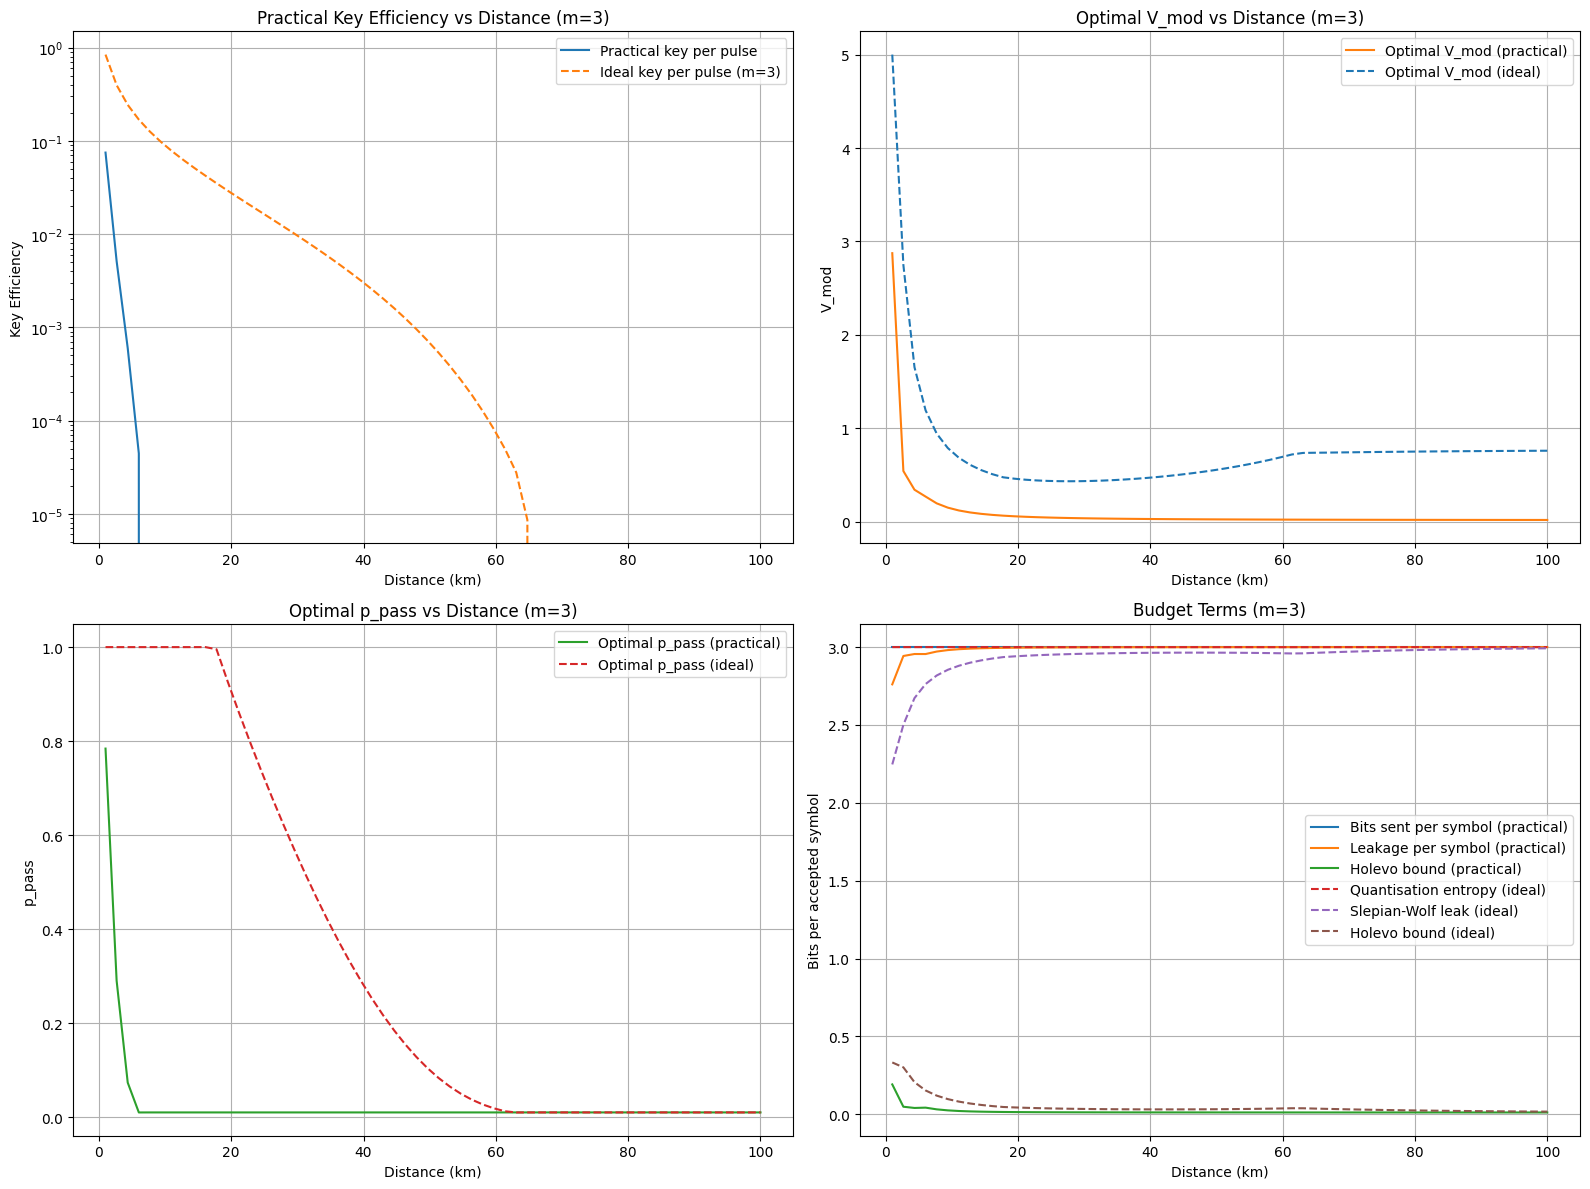

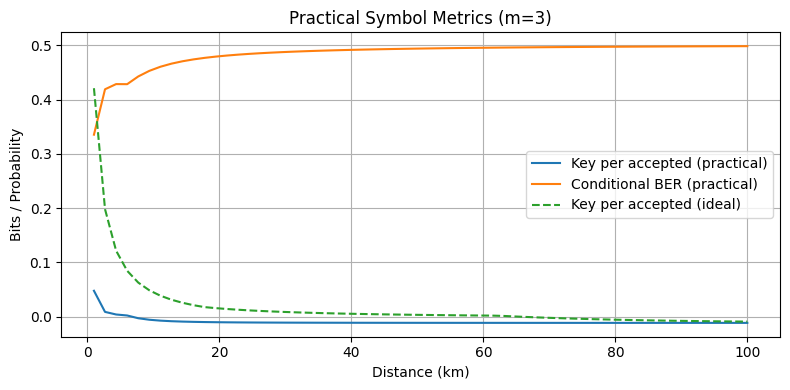

In [18]:
practical_coding_efficiency_m3 = 1.0
practical_bits_model_m3 = 'H_Tx'

practical_key_per_pulse_m3 = []
practical_key_per_accepted_m3 = []
practical_error_rates_m3 = []
practical_leakage_m3 = []
practical_holevo_bounds_m3 = []
practical_bits_sent_m3 = []
practical_opt_v_mods_m3 = []
practical_opt_p_passes_m3 = []
practical_metrics_m3 = []

initial_guess_practical_m3 = np.array([np.mean(v_mod_bounds), 0.8])
bounds_practical_m3 = [v_mod_bounds, p_pass_bounds]

for distance in tqdm(distances, desc='Optimising practical m=3'):
    transmittance = fibre_transmittance(distance)

    def evaluate_practical_metrics_m3(v_mod_candidate: float, p_pass_candidate: float):
        gbsr_instance = GBSR(
            3,
            float(v_mod_candidate),
            transmittance,
            excess_noise,
            practical_coding_efficiency=practical_coding_efficiency_m3,
        )
        tau_arr = gbsr_instance.build_equiprobable_tau()
        g_arr = gbsr_instance.generate_g_arr_from_p_pass(float(p_pass_candidate), tau_arr)
        metrics = gbsr_instance.evaluate_practical_key_efficiency(
            tau_arr,
            g_arr,
            bits_model=practical_bits_model_m3,
            include_delta_qct=False,
            bit_assignment='Gray',
        )
        return dict(metrics), gbsr_instance

    def negative_practical_m3(params):
        v_mod_candidate, p_pass_candidate = params
        v_mod_checked = float(np.clip(v_mod_candidate, *v_mod_bounds))
        p_pass_checked = float(np.clip(p_pass_candidate, *p_pass_bounds))
        try:
            metrics_candidate, _ = evaluate_practical_metrics_m3(v_mod_checked, p_pass_checked)
        except Exception:
            return np.inf
        return -metrics_candidate['key_per_pulse']

    optimisation_result = minimize(
        negative_practical_m3,
        x0=initial_guess_practical_m3,
        bounds=bounds_practical_m3,
        method='Powell',
    )

    if not optimisation_result.success or not np.isfinite(optimisation_result.fun):
        grid_v_mod = np.linspace(v_mod_bounds[0], v_mod_bounds[1], 25)
        grid_p_pass = np.linspace(p_pass_bounds[0], p_pass_bounds[1], 25)
        best_value = np.inf
        best_pair = None
        for v_candidate in grid_v_mod:
            for p_candidate in grid_p_pass:
                value = negative_practical_m3((v_candidate, p_candidate))
                if value < best_value:
                    best_value = value
                    best_pair = (v_candidate, p_candidate)
        if best_pair is None:
            raise RuntimeError(f"Failed to find feasible parameters at distance {distance:.2f} km for practical m=3")
        best_v_mod, best_p_pass = best_pair
    else:
        best_v_mod, best_p_pass = optimisation_result.x

    best_v_mod = float(np.clip(best_v_mod, *v_mod_bounds))
    best_p_pass = float(np.clip(best_p_pass, *p_pass_bounds))
    best_metrics, best_gbsr_instance = evaluate_practical_metrics_m3(best_v_mod, best_p_pass)

    practical_key_per_pulse_m3.append(best_metrics['key_per_pulse'])
    practical_key_per_accepted_m3.append(best_metrics['key_per_accepted_symbol'])
    practical_error_rates_m3.append(best_metrics['error_rate'])
    practical_leakage_m3.append(best_metrics['leaked_info_per_symbol'])
    practical_holevo_bounds_m3.append(best_metrics['holevo_bound'])
    practical_bits_sent_m3.append(best_metrics['bits_sent_per_symbol'])
    practical_opt_v_mods_m3.append(best_v_mod)
    practical_opt_p_passes_m3.append(best_metrics['p_pass'])
    practical_metrics_m3.append(best_metrics)

    initial_guess_practical_m3 = np.array([best_v_mod, best_p_pass])

practical_key_per_pulse_m3 = np.array(practical_key_per_pulse_m3)
practical_key_per_accepted_m3 = np.array(practical_key_per_accepted_m3)
practical_error_rates_m3 = np.array(practical_error_rates_m3)
practical_leakage_m3 = np.array(practical_leakage_m3)
practical_holevo_bounds_m3 = np.array(practical_holevo_bounds_m3)
practical_bits_sent_m3 = np.array(practical_bits_sent_m3)
practical_opt_v_mods_m3 = np.array(practical_opt_v_mods_m3)
practical_opt_p_passes_m3 = np.array(practical_opt_p_passes_m3)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].plot(distances, practical_key_per_pulse_m3, label='Practical key per pulse')
if 'key_per_pulse_m3' in globals():
    axes[0, 0].plot(distances, np.asarray(key_per_pulse_m3), linestyle='--', label='Ideal key per pulse (m=3)')
axes[0, 0].set_xlabel('Distance (km)')
axes[0, 0].set_ylabel('Key Efficiency')
axes[0, 0].set_title('Practical Key Efficiency vs Distance (m=3)')
axes[0, 0].set_yscale('log')
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].plot(distances, practical_opt_v_mods_m3, color='tab:orange', label='Optimal V_mod (practical)')
if 'optimal_v_mods_m3' in globals():
    axes[0, 1].plot(distances, np.asarray(optimal_v_mods_m3), linestyle='--', color='tab:blue', label='Optimal V_mod (ideal)')
axes[0, 1].set_xlabel('Distance (km)')
axes[0, 1].set_ylabel('V_mod')
axes[0, 1].set_title('Optimal V_mod vs Distance (m=3)')
axes[0, 1].legend()
axes[0, 1].grid(True)

axes[1, 0].plot(distances, practical_opt_p_passes_m3, color='tab:green', label='Optimal p_pass (practical)')
if 'optimal_p_passes_m3' in globals():
    axes[1, 0].plot(distances, np.asarray(optimal_p_passes_m3), linestyle='--', color='tab:red', label='Optimal p_pass (ideal)')
axes[1, 0].set_xlabel('Distance (km)')
axes[1, 0].set_ylabel('p_pass')
axes[1, 0].set_title('Optimal p_pass vs Distance (m=3)')
axes[1, 0].legend()
axes[1, 0].grid(True)

axes[1, 1].plot(distances, practical_bits_sent_m3, label='Bits sent per symbol (practical)')
axes[1, 1].plot(distances, practical_leakage_m3, label='Leakage per symbol (practical)')
axes[1, 1].plot(distances, practical_holevo_bounds_m3, label='Holevo bound (practical)')
if 'quantisation_entropies_m3' in globals():
    axes[1, 1].plot(distances, np.asarray(quantisation_entropies_m3), linestyle='--', label='Quantisation entropy (ideal)')
if 'slepian_wolf_leaks_m3' in globals():
    axes[1, 1].plot(distances, np.asarray(slepian_wolf_leaks_m3), linestyle='--', label='Slepian-Wolf leak (ideal)')
if 'holevo_bounds_m3' in globals():
    axes[1, 1].plot(distances, np.asarray(holevo_bounds_m3), linestyle='--', label='Holevo bound (ideal)')
axes[1, 1].set_xlabel('Distance (km)')
axes[1, 1].set_ylabel('Bits per accepted symbol')
axes[1, 1].set_title('Budget Terms (m=3)')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(distances, practical_key_per_accepted_m3, label='Key per accepted (practical)')
ax.plot(distances, practical_error_rates_m3, label='Conditional BER (practical)')
if 'key_per_accepted_m3' in globals():
    ax.plot(distances, np.asarray(key_per_accepted_m3), linestyle='--', label='Key per accepted (ideal)')
ax.set_xlabel('Distance (km)')
ax.set_ylabel('Bits / Probability')
ax.set_title('Practical Symbol Metrics (m=3)')
ax.legend()
ax.grid(True)
plt.tight_layout(
)
plt.show()


## Comparing Practical $m = 1, 2, 3$ Results

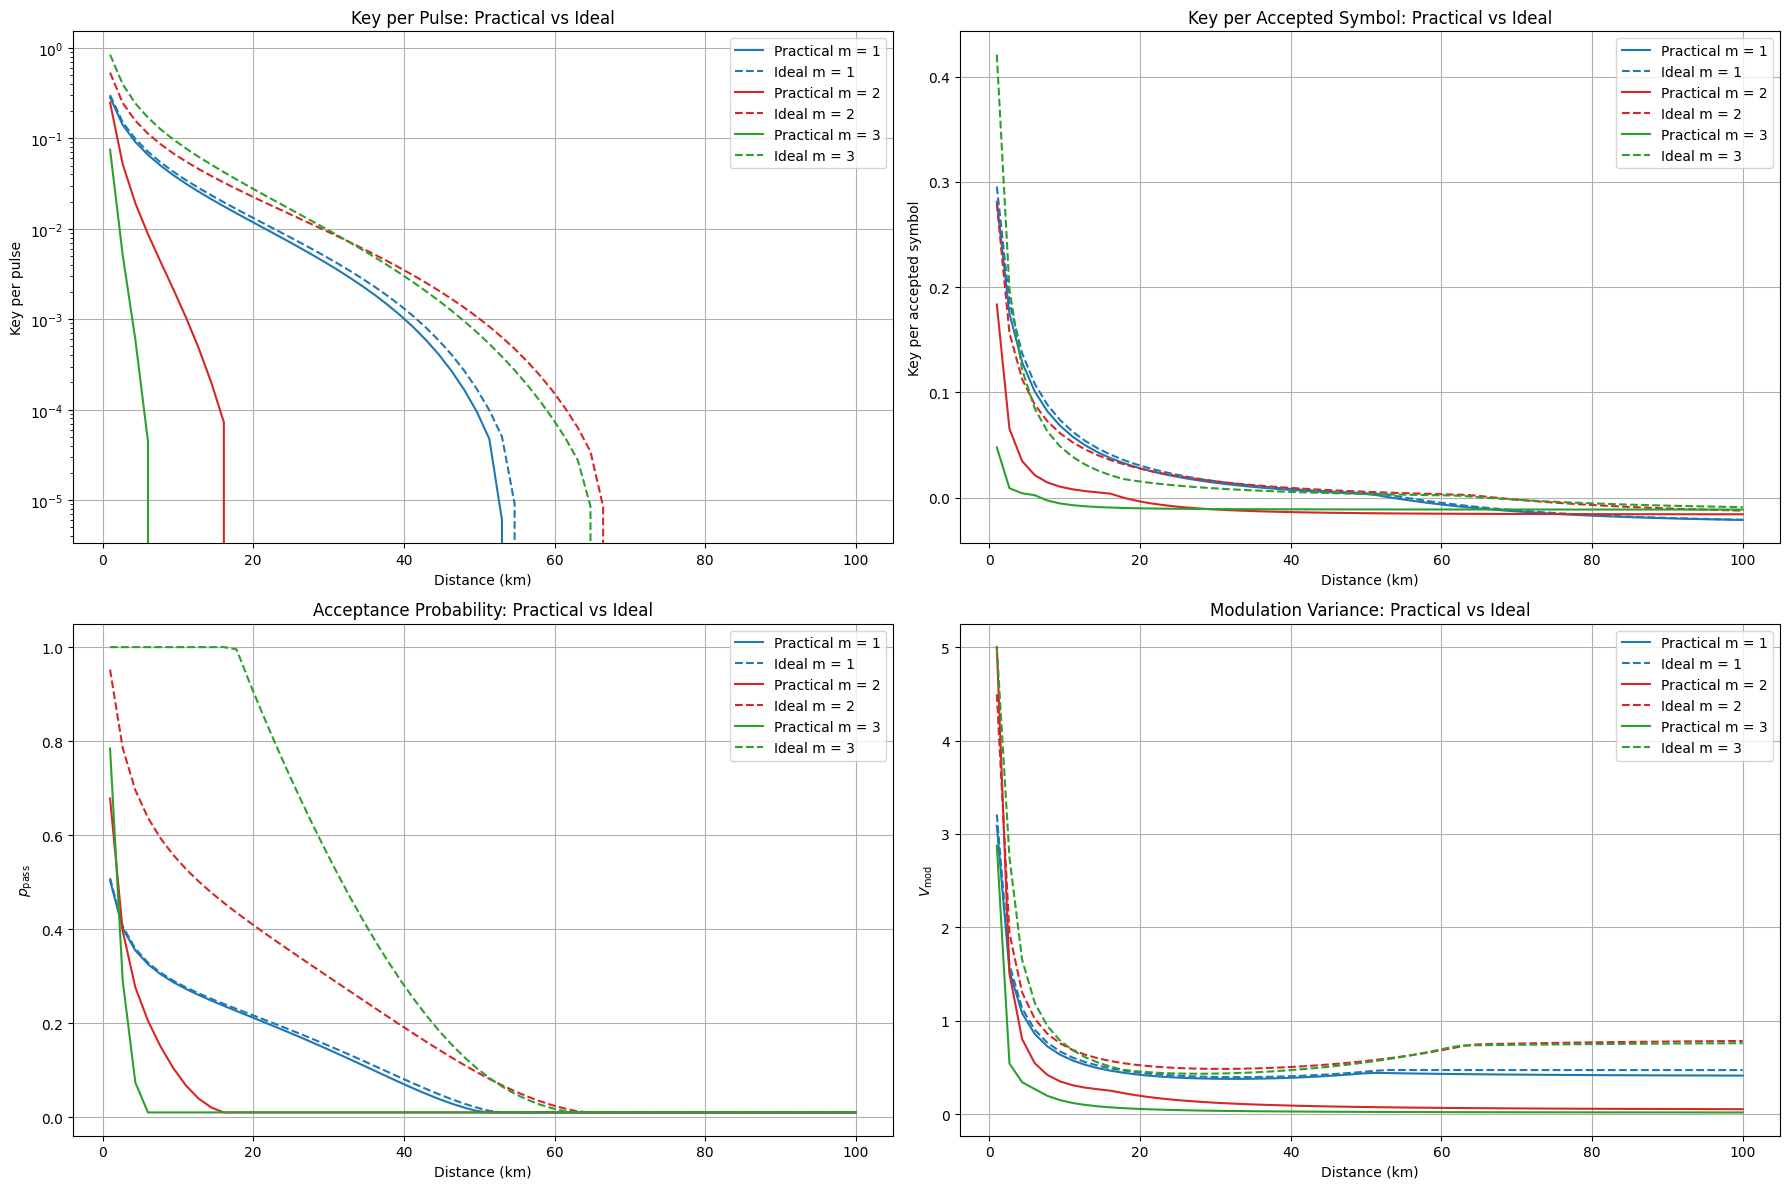

In [19]:

# Comparative overview: practical vs ideal performance for m = 1, 2, 3
color_map = {1: 'tab:blue', 2: 'tab:red', 3: 'tab:green'}
label_map = {1: 'm = 1', 2: 'm = 2', 3: 'm = 3'}

practical_key_per_pulse = {
    1: practical_key_per_pulse_m1,
    2: practical_key_per_pulse_m2,
    3: practical_key_per_pulse_m3,
}
ideal_key_per_pulse = {
    1: np.asarray(key_per_pulse_m1),
    2: np.asarray(key_per_pulse_m2),
    3: np.asarray(key_per_pulse_m3),
}
practical_key_per_accepted = {
    1: practical_key_per_accepted_m1,
    2: practical_key_per_accepted_m2,
    3: practical_key_per_accepted_m3,
}
ideal_key_per_accepted = {
    1: np.asarray(key_per_accepted_m1),
    2: np.asarray(key_per_accepted_m2),
    3: np.asarray(key_per_accepted_m3),
}
practical_p_pass = {
    1: practical_opt_p_passes_m1,
    2: practical_opt_p_passes_m2,
    3: practical_opt_p_passes_m3,
}
ideal_p_pass = {
    1: np.asarray(optimal_p_passes_m1),
    2: np.asarray(optimal_p_passes_m2),
    3: np.asarray(optimal_p_passes_m3),
}
practical_v_mod = {
    1: practical_opt_v_mods_m1,
    2: practical_opt_v_mods_m2,
    3: practical_opt_v_mods_m3,
}
ideal_v_mod = {
    1: np.asarray(optimal_v_mods_m1),
    2: np.asarray(optimal_v_mods_m2),
    3: np.asarray(optimal_v_mods_m3),
}

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Key per pulse comparison
ax = axes[0, 0]
for m, color in color_map.items():
    ax.plot(distances, practical_key_per_pulse[m], color=color, linestyle='-', label=f'Practical {label_map[m]}')
    ax.plot(distances, ideal_key_per_pulse[m], color=color, linestyle='--', label=f'Ideal {label_map[m]}')
ax.set_xlabel('Distance (km)')
ax.set_ylabel('Key per pulse')
ax.set_title('Key per Pulse: Practical vs Ideal')
ax.set_yscale('log')
ax.legend()
ax.grid(True)

# Key per accepted symbol comparison
ax = axes[0, 1]
for m, color in color_map.items():
    ax.plot(distances, practical_key_per_accepted[m], color=color, linestyle='-', label=f'Practical {label_map[m]}')
    ax.plot(distances, ideal_key_per_accepted[m], color=color, linestyle='--', label=f'Ideal {label_map[m]}')
ax.set_xlabel('Distance (km)')
ax.set_ylabel('Key per accepted symbol')
ax.set_title('Key per Accepted Symbol: Practical vs Ideal')
ax.legend()
ax.grid(True)

# p_pass comparison
ax = axes[1, 0]
for m, color in color_map.items():
    ax.plot(distances, practical_p_pass[m], color=color, linestyle='-', label=f'Practical {label_map[m]}')
    ax.plot(distances, ideal_p_pass[m], color=color, linestyle='--', label=f'Ideal {label_map[m]}')
ax.set_xlabel('Distance (km)')
ax.set_ylabel('$p_{\mathrm{pass}}$')
ax.set_title('Acceptance Probability: Practical vs Ideal')
ax.legend()
ax.grid(True)

# V_mod comparison
ax = axes[1, 1]
for m, color in color_map.items():
    ax.plot(distances, practical_v_mod[m], color=color, linestyle='-', label=f'Practical {label_map[m]}')
    ax.plot(distances, ideal_v_mod[m], color=color, linestyle='--', label=f'Ideal {label_map[m]}')
ax.set_xlabel('Distance (km)')
ax.set_ylabel('$V_{\mathrm{mod}}$')
ax.set_title('Modulation Variance: Practical vs Ideal')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()


# Bit-Level Key Efficiency

This section evaluates the key efficiencies at the bit-plane level. This straddles somewhere between the practical key rate (which uses one LDPC with all bit-planes treated identically) and the optimal key rate. The improvement is in the form of the use of bit planes. Here, we can still pass it to 'one code' but we still use the per-plane error rates to calculate the leakage more accurately. Therefore, $m = 2, 3$ will be less punished when compared to the practical key rate above.

Here, when `mode="one_code"`, we calculate the leakage as $\text{LEAK}_\text{EC} = m(1 - \eta_c\sum_k(1-h_2(e_k)))$. 

## $m = 1$

Like the 'theoretical' and the 'practical' case, we need to optimise $p_\text{pass}$ and $V_\text{mod}$ for each distance. 

Optimising bit-plane m=1:   0%|          | 0/60 [00:00<?, ?it/s]

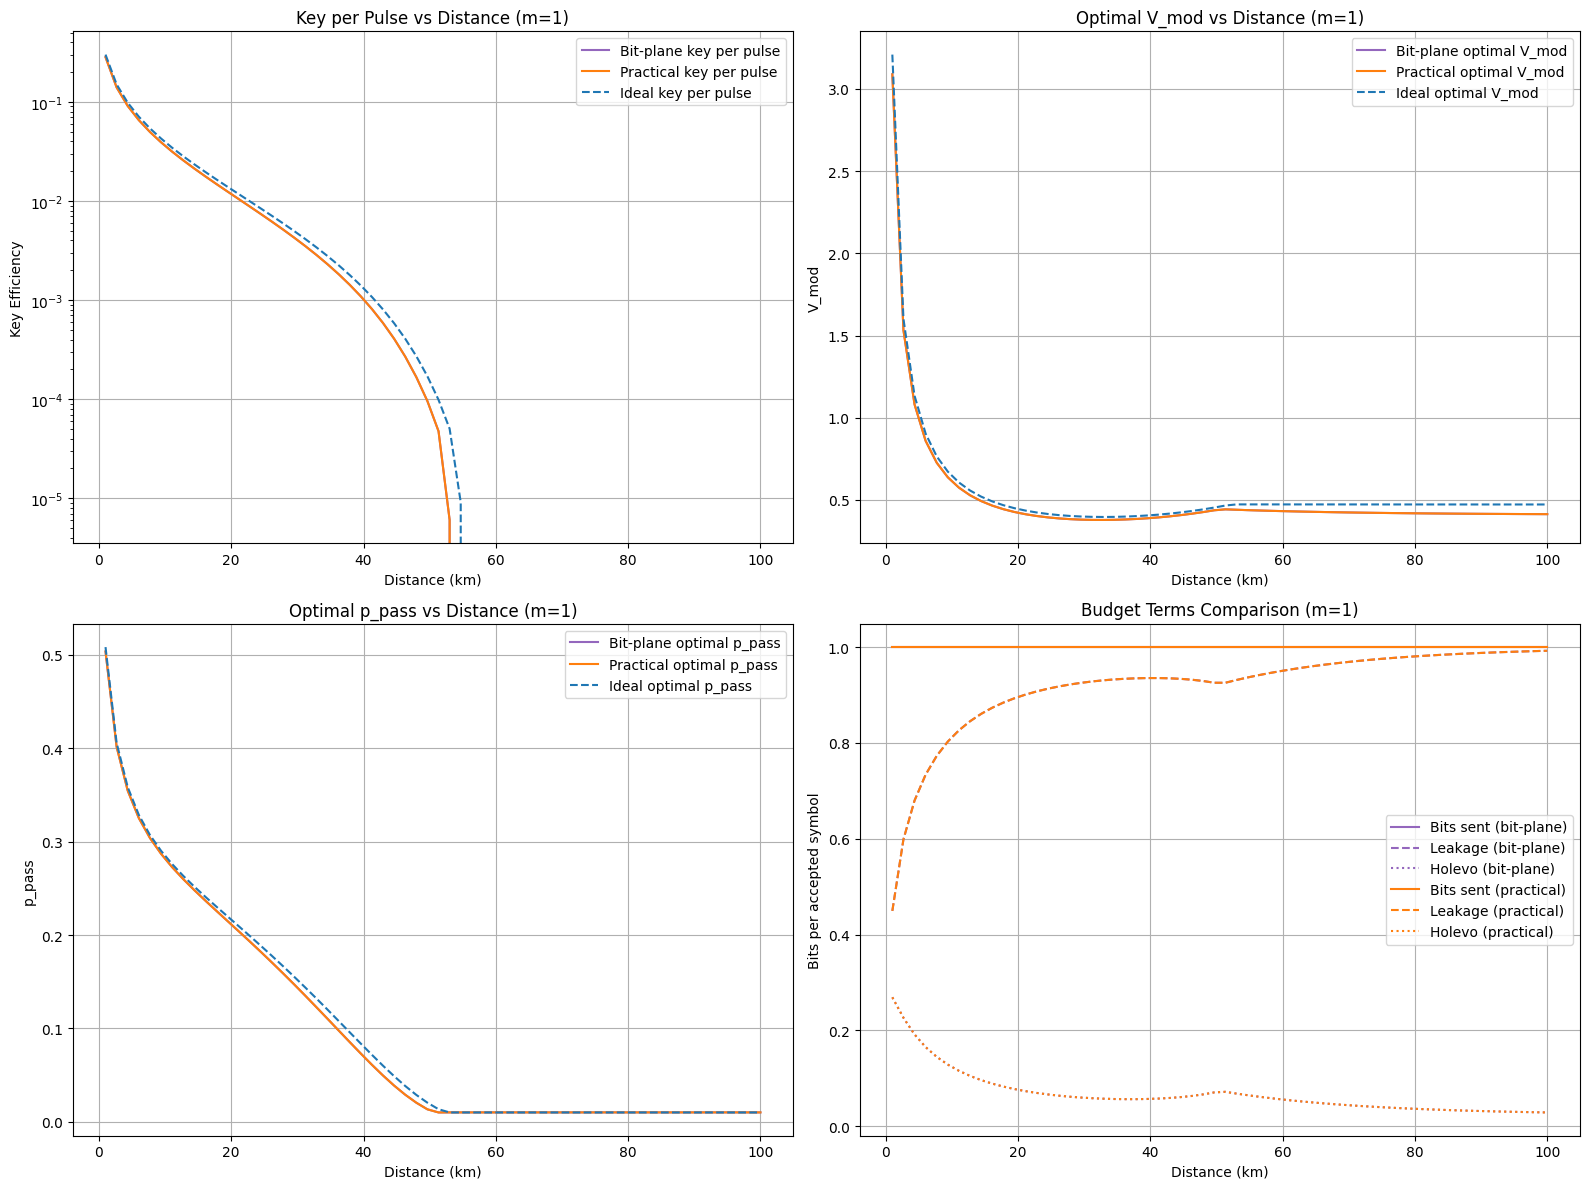

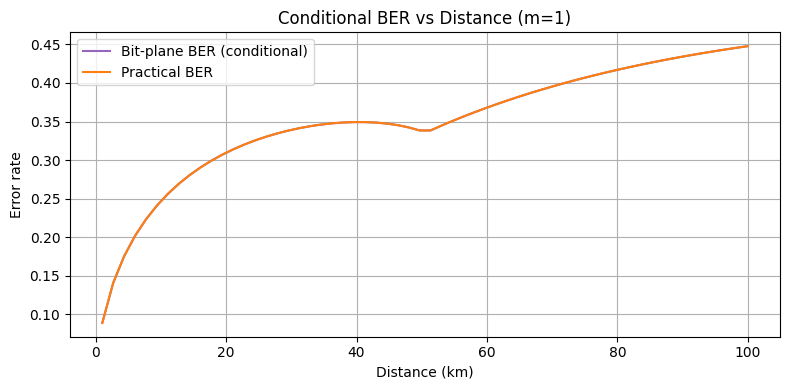

In [20]:
bit_plane_key_per_pulse_m2 = []
bit_plane_key_per_accepted_m2 = []
bit_plane_plane_ber_m2 = []
bit_plane_leakage_m2 = []
bit_plane_holevo_bounds_m2 = []
bit_plane_bits_sent_m2 = []
bit_plane_opt_v_mods_m2 = []
bit_plane_opt_p_passes_m2 = []
bit_plane_metrics_m2 = []

initial_guess_bit_plane_m2 = np.array([np.mean(v_mod_bounds), 0.8])
bounds_bit_plane_m2 = [v_mod_bounds, p_pass_bounds]

for distance in tqdm(distances, desc='Optimising bit-plane m=2'):
    transmittance = fibre_transmittance(distance)

    def evaluate_bit_plane_metrics_m2(v_mod_candidate: float, p_pass_candidate: float):
        gbsr_instance = GBSR(
            2,
            float(v_mod_candidate),
            transmittance,
            excess_noise,
            practical_coding_efficiency=practical_coding_efficiency,
        )
        tau_arr = gbsr_instance.build_equiprobable_tau()
        g_arr = gbsr_instance.generate_g_arr_from_p_pass(float(p_pass_candidate), tau_arr)
        metrics = gbsr_instance.evaluate_key_efficiency_via_bit_planes(
            tau_arr,
            g_arr,
            bit_assignment='Gray',
            mode=bit_plane_mode,
            eta_c=bit_plane_eta_c,
            include_delta_qct=False,
        )
        return dict(metrics), gbsr_instance

    def negative_bit_plane_m2(params):
        v_mod_candidate, p_pass_candidate = params
        v_mod_checked = float(np.clip(v_mod_candidate, *v_mod_bounds))
        p_pass_checked = float(np.clip(p_pass_candidate, *p_pass_bounds))
        try:
            metrics_candidate, _ = evaluate_bit_plane_metrics_m2(v_mod_checked, p_pass_checked)
        except Exception:
            return np.inf
        return -metrics_candidate['key_per_pulse']

    optimisation_result = minimize(
        negative_bit_plane_m2,
        x0=initial_guess_bit_plane_m2,
        bounds=bounds_bit_plane_m2,
        method='Powell',
    )

    if not optimisation_result.success or not np.isfinite(optimisation_result.fun):
        grid_v_mod = np.linspace(v_mod_bounds[0], v_mod_bounds[1], 25)
        grid_p_pass = np.linspace(p_pass_bounds[0], p_pass_bounds[1], 25)
        best_value = np.inf
        best_pair = None
        for v_candidate in grid_v_mod:
            for p_candidate in grid_p_pass:
                value = negative_bit_plane_m2((v_candidate, p_candidate))
                if value < best_value:
                    best_value = value
                    best_pair = (v_candidate, p_candidate)
        if best_pair is None:
            raise RuntimeError(f"Failed to find feasible parameters at distance {distance:.2f} km for bit-plane m=2")
        best_v_mod, best_p_pass = best_pair
    else:
        best_v_mod, best_p_pass = optimisation_result.x

    best_v_mod = float(np.clip(best_v_mod, *v_mod_bounds))
    best_p_pass = float(np.clip(best_p_pass, *p_pass_bounds))
    best_metrics, best_gbsr_instance = evaluate_bit_plane_metrics_m2(best_v_mod, best_p_pass)

    bit_plane_key_per_pulse_m2.append(best_metrics['key_per_pulse'])
    bit_plane_key_per_accepted_m2.append(best_metrics['key_per_accepted_symbol'])
    bit_plane_plane_ber_m2.append(best_metrics['e_k'])
    bit_plane_leakage_m2.append(best_metrics['leaked_info_per_symbol'])
    bit_plane_holevo_bounds_m2.append(best_metrics['holevo_bound'])
    bit_plane_bits_sent_m2.append(best_metrics['bits_sent_per_symbol'])
    bit_plane_opt_v_mods_m2.append(best_v_mod)
    bit_plane_opt_p_passes_m2.append(best_metrics['p_pass'])
    bit_plane_metrics_m2.append(best_metrics)

    initial_guess_bit_plane_m2 = np.array([best_v_mod, best_p_pass])

bit_plane_key_per_pulse_m2 = np.array(bit_plane_key_per_pulse_m2)
bit_plane_key_per_accepted_m2 = np.array(bit_plane_key_per_accepted_m2)
bit_plane_leakage_m2 = np.array(bit_plane_leakage_m2)
bit_plane_holevo_bounds_m2 = np.array(bit_plane_holevo_bounds_m2)
bit_plane_bits_sent_m2 = np.array(bit_plane_bits_sent_m2)
bit_plane_opt_v_mods_m2 = np.array(bit_plane_opt_v_mods_m2)
bit_plane_opt_p_passes_m2 = np.array(bit_plane_opt_p_passes_m2)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].plot(distances, bit_plane_key_per_pulse_m2, label='Bit-plane key per pulse', color='tab:purple')
axes[0, 0].plot(distances, practical_key_per_pulse_m2, label='Practical key per pulse', color='tab:orange', linestyle='-')
axes[0, 0].plot(distances, key_per_pulse_m2, label='Ideal key per pulse', color='tab:blue', linestyle='--')
axes[0, 0].set_xlabel('Distance (km)')
axes[0, 0].set_ylabel('Key Efficiency')
axes[0, 0].set_title('Key per Pulse vs Distance (m=2)')
axes[0, 0].set_yscale('log')
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].plot(distances, bit_plane_opt_v_mods_m2, label='Bit-plane optimal V_mod', color='tab:purple')
axes[0, 1].plot(distances, practical_opt_v_mods_m2, label='Practical optimal V_mod', color='tab:orange')
axes[0, 1].plot(distances, optimal_v_mods_m2, label='Ideal optimal V_mod', color='tab:blue', linestyle='--')
axes[0, 1].set_xlabel('Distance (km)')
axes[0, 1].set_ylabel('V_mod')
axes[0, 1].set_title('Optimal V_mod vs Distance (m=2)')
axes[0, 1].legend()
axes[0, 1].grid(True)

axes[1, 0].plot(distances, bit_plane_opt_p_passes_m2, label='Bit-plane optimal p_pass', color='tab:purple')
axes[1, 0].plot(distances, practical_opt_p_passes_m2, label='Practical optimal p_pass', color='tab:orange')
axes[1, 0].plot(distances, optimal_p_passes_m2, label='Ideal optimal p_pass', color='tab:blue', linestyle='--')
axes[1, 0].set_xlabel('Distance (km)')
axes[1, 0].set_ylabel('p_pass')
axes[1, 0].set_title('Optimal p_pass vs Distance (m=2)')
axes[1, 0].legend()
axes[1, 0].grid(True)

axes[1, 1].plot(distances, bit_plane_bits_sent_m2, label='Bits sent (bit-plane)', color='tab:purple')
axes[1, 1].plot(distances, bit_plane_leakage_m2, label='Leakage (bit-plane)', color='tab:purple', linestyle='--')
axes[1, 1].plot(distances, bit_plane_holevo_bounds_m2, label='Holevo (bit-plane)', color='tab:purple', linestyle=':')
axes[1, 1].plot(distances, practical_bits_sent_m2, label='Bits sent (practical)', color='tab:orange', linestyle='-')
axes[1, 1].plot(distances, practical_leakage_m2, label='Leakage (practical)', color='tab:orange', linestyle='--')
axes[1, 1].plot(distances, practical_holevo_bounds_m2, label='Holevo (practical)', color='tab:orange', linestyle=':')
axes[1, 1].set_xlabel('Distance (km)')
axes[1, 1].set_ylabel('Bits per accepted symbol')
axes[1, 1].set_title('Budget Terms Comparison (m=2)')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(distances, bit_plane_key_per_accepted_m2, label='Key per accepted (bit-plane)', color='tab:purple')
ax.plot(distances, practical_key_per_accepted_m2, label='Key per accepted (practical)', color='tab:orange')
ax.plot(distances, key_per_accepted_m2, label='Key per accepted (ideal)', color='tab:blue', linestyle='--')
ax.set_xlabel('Distance (km)')
ax.set_ylabel('Bits per accepted symbol')
ax.set_title('Key per Accepted Symbol (m=2)')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(distances, [plane[0] for plane in bit_plane_plane_ber_m2], label='Plane 0 BER (conditional)', color='tab:purple')
ax.plot(distances, [plane[1] for plane in bit_plane_plane_ber_m2], label='Plane 1 BER (conditional)', color='tab:purple', linestyle='--')
ax.plot(distances, practical_error_rates_m2, label='Practical BER', color='tab:orange')
ax.set_xlabel('Distance (km)')
ax.set_ylabel('Error rate')
ax.set_title('Conditional BER vs Distance (m=2)')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


## $m = 2$

Optimising bit-plane m=2:   0%|          | 0/60 [00:00<?, ?it/s]

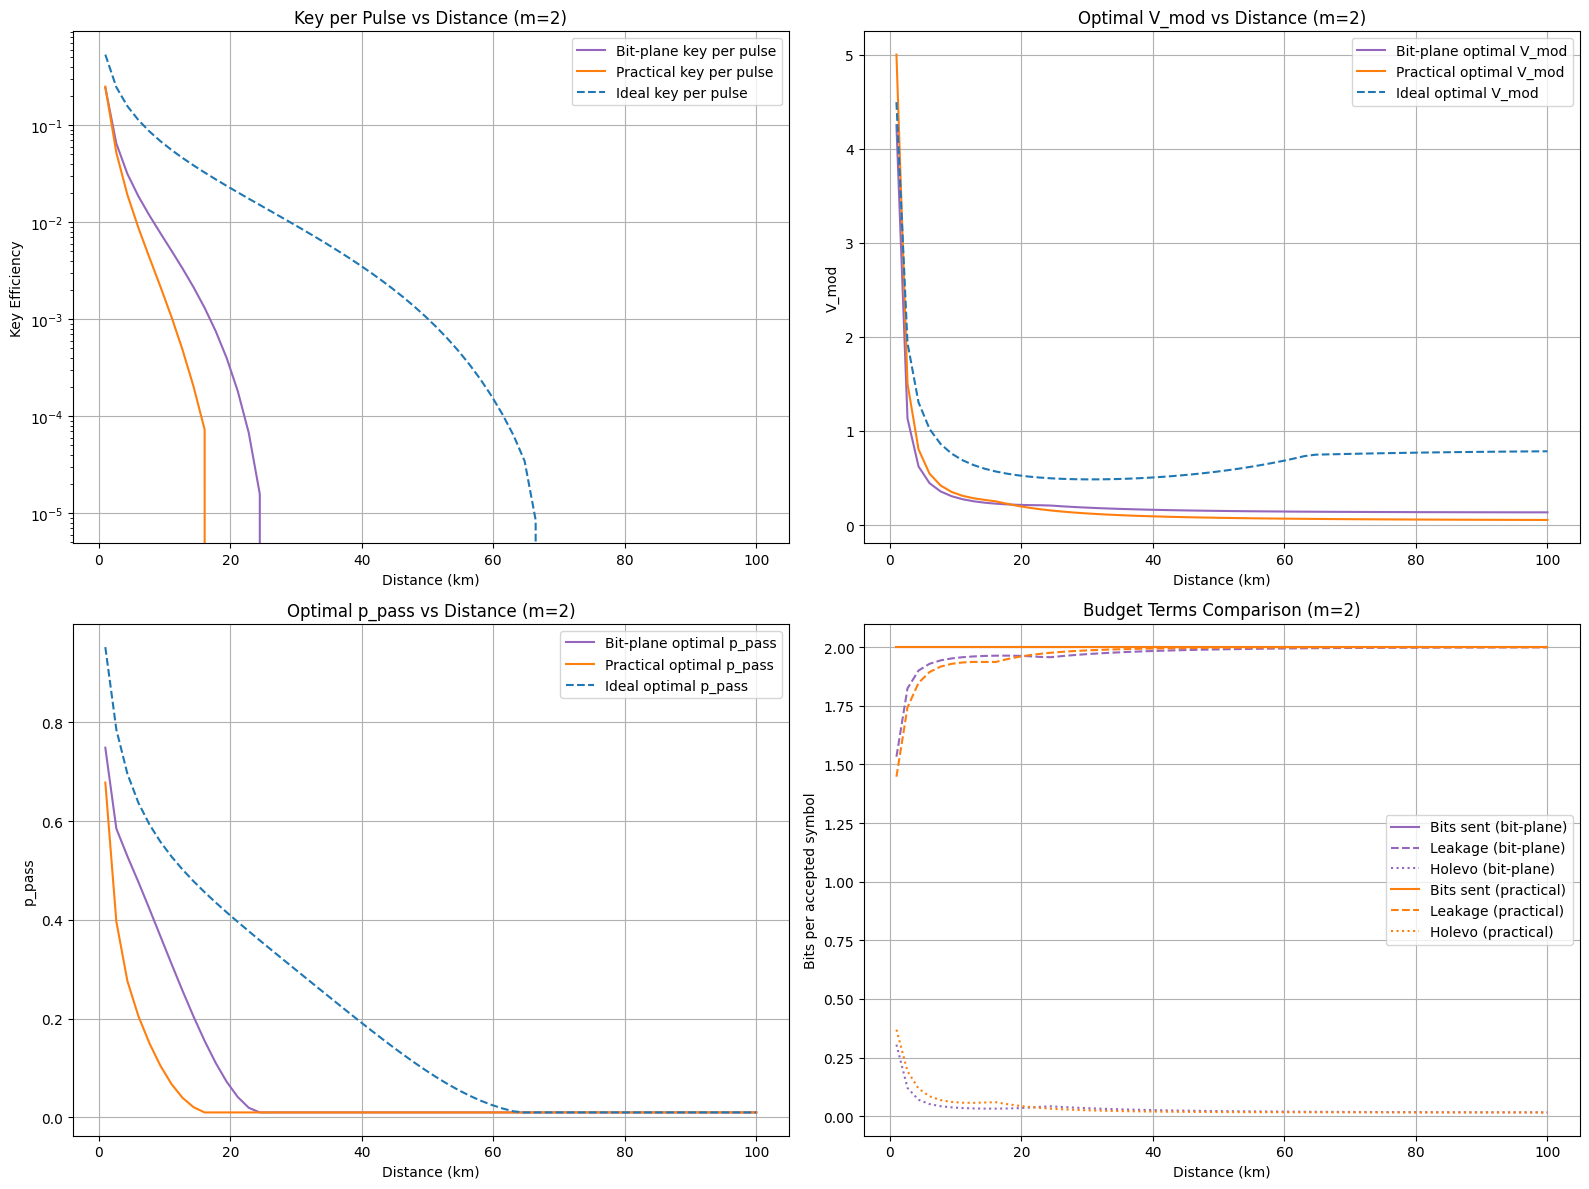

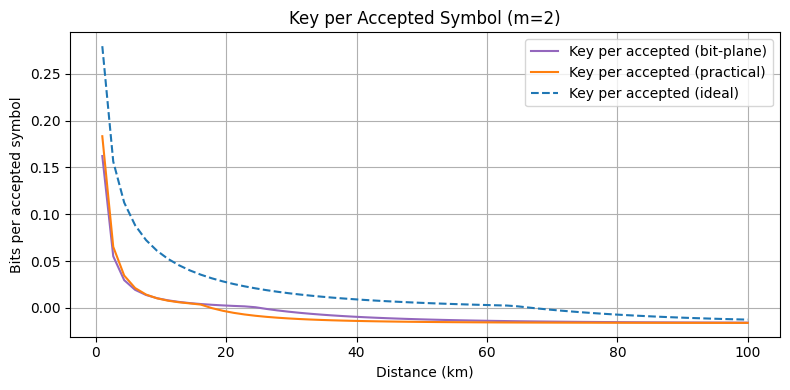

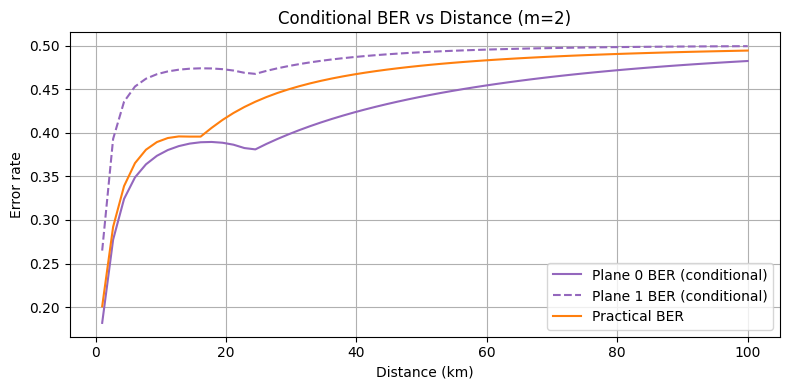

In [21]:
bit_plane_mode = 'one_code'
bit_plane_eta_c = practical_coding_efficiency

bit_plane_key_per_pulse_m2 = []
bit_plane_key_per_accepted_m2 = []
bit_plane_plane_ber_m2 = []
bit_plane_leakage_m2 = []
bit_plane_holevo_bounds_m2 = []
bit_plane_bits_sent_m2 = []
bit_plane_opt_v_mods_m2 = []
bit_plane_opt_p_passes_m2 = []
bit_plane_metrics_m2 = []

initial_guess_bit_plane_m2 = np.array([np.mean(v_mod_bounds), 0.8])
bounds_bit_plane_m2 = [v_mod_bounds, p_pass_bounds]

for distance in tqdm(distances, desc='Optimising bit-plane m=2'):
    transmittance = fibre_transmittance(distance)

    def evaluate_bit_plane_metrics_m2(v_mod_candidate: float, p_pass_candidate: float):
        gbsr_instance = GBSR(
            2,
            float(v_mod_candidate),
            transmittance,
            excess_noise,
            practical_coding_efficiency=practical_coding_efficiency,
        )
        tau_arr = gbsr_instance.build_equiprobable_tau()
        g_arr = gbsr_instance.generate_g_arr_from_p_pass(float(p_pass_candidate), tau_arr)
        metrics = gbsr_instance.evaluate_key_efficiency_via_bit_planes(
            tau_arr,
            g_arr,
            bit_assignment='Gray',
            mode=bit_plane_mode,
            eta_c=bit_plane_eta_c,
            include_delta_qct=False,
        )
        return dict(metrics), gbsr_instance

    def negative_bit_plane_m2(params):
        v_mod_candidate, p_pass_candidate = params
        v_mod_checked = float(np.clip(v_mod_candidate, *v_mod_bounds))
        p_pass_checked = float(np.clip(p_pass_candidate, *p_pass_bounds))
        try:
            metrics_candidate, _ = evaluate_bit_plane_metrics_m2(v_mod_checked, p_pass_checked)
        except Exception:
            return np.inf
        return -metrics_candidate['key_per_pulse']

    optimisation_result = minimize(
        negative_bit_plane_m2,
        x0=initial_guess_bit_plane_m2,
        bounds=bounds_bit_plane_m2,
        method='Powell',
    )

    if not optimisation_result.success or not np.isfinite(optimisation_result.fun):
        grid_v_mod = np.linspace(v_mod_bounds[0], v_mod_bounds[1], 25)
        grid_p_pass = np.linspace(p_pass_bounds[0], p_pass_bounds[1], 25)
        best_value = np.inf
        best_pair = None
        for v_candidate in grid_v_mod:
            for p_candidate in grid_p_pass:
                value = negative_bit_plane_m2((v_candidate, p_candidate))
                if value < best_value:
                    best_value = value
                    best_pair = (v_candidate, p_candidate)
        if best_pair is None:
            raise RuntimeError(f"Failed to find feasible parameters at distance {distance:.2f} km for bit-plane m=2")
        best_v_mod, best_p_pass = best_pair
    else:
        best_v_mod, best_p_pass = optimisation_result.x

    best_v_mod = float(np.clip(best_v_mod, *v_mod_bounds))
    best_p_pass = float(np.clip(best_p_pass, *p_pass_bounds))
    best_metrics, best_gbsr_instance = evaluate_bit_plane_metrics_m2(best_v_mod, best_p_pass)

    bit_plane_key_per_pulse_m2.append(best_metrics['key_per_pulse'])
    bit_plane_key_per_accepted_m2.append(best_metrics['key_per_accepted_symbol'])
    bit_plane_plane_ber_m2.append(best_metrics['e_k'])
    bit_plane_leakage_m2.append(best_metrics['leaked_info_per_symbol'])
    bit_plane_holevo_bounds_m2.append(best_metrics['holevo_bound'])
    bit_plane_bits_sent_m2.append(best_metrics['bits_sent_per_symbol'])
    bit_plane_opt_v_mods_m2.append(best_v_mod)
    bit_plane_opt_p_passes_m2.append(best_metrics['p_pass'])
    bit_plane_metrics_m2.append(best_metrics)

    initial_guess_bit_plane_m2 = np.array([best_v_mod, best_p_pass])

bit_plane_key_per_pulse_m2 = np.array(bit_plane_key_per_pulse_m2)
bit_plane_key_per_accepted_m2 = np.array(bit_plane_key_per_accepted_m2)
bit_plane_leakage_m2 = np.array(bit_plane_leakage_m2)
bit_plane_holevo_bounds_m2 = np.array(bit_plane_holevo_bounds_m2)
bit_plane_bits_sent_m2 = np.array(bit_plane_bits_sent_m2)
bit_plane_opt_v_mods_m2 = np.array(bit_plane_opt_v_mods_m2)
bit_plane_opt_p_passes_m2 = np.array(bit_plane_opt_p_passes_m2)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].plot(distances, bit_plane_key_per_pulse_m2, label='Bit-plane key per pulse', color='tab:purple')
axes[0, 0].plot(distances, practical_key_per_pulse_m2, label='Practical key per pulse', color='tab:orange')
axes[0, 0].plot(distances, key_per_pulse_m2, label='Ideal key per pulse', color='tab:blue', linestyle='--')
axes[0, 0].set_xlabel('Distance (km)')
axes[0, 0].set_ylabel('Key Efficiency')
axes[0, 0].set_title('Key per Pulse vs Distance (m=2)')
axes[0, 0].set_yscale('log')
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].plot(distances, bit_plane_opt_v_mods_m2, label='Bit-plane optimal V_mod', color='tab:purple')
axes[0, 1].plot(distances, practical_opt_v_mods_m2, label='Practical optimal V_mod', color='tab:orange')
axes[0, 1].plot(distances, optimal_v_mods_m2, label='Ideal optimal V_mod', color='tab:blue', linestyle='--')
axes[0, 1].set_xlabel('Distance (km)')
axes[0, 1].set_ylabel('V_mod')
axes[0, 1].set_title('Optimal V_mod vs Distance (m=2)')
axes[0, 1].legend()
axes[0, 1].grid(True)

axes[1, 0].plot(distances, bit_plane_opt_p_passes_m2, label='Bit-plane optimal p_pass', color='tab:purple')
axes[1, 0].plot(distances, practical_opt_p_passes_m2, label='Practical optimal p_pass', color='tab:orange')
axes[1, 0].plot(distances, optimal_p_passes_m2, label='Ideal optimal p_pass', color='tab:blue', linestyle='--')
axes[1, 0].set_xlabel('Distance (km)')
axes[1, 0].set_ylabel('p_pass')
axes[1, 0].set_title('Optimal p_pass vs Distance (m=2)')
axes[1, 0].legend()
axes[1, 0].grid(True)

axes[1, 1].plot(distances, bit_plane_bits_sent_m2, label='Bits sent (bit-plane)', color='tab:purple')
axes[1, 1].plot(distances, bit_plane_leakage_m2, label='Leakage (bit-plane)', color='tab:purple', linestyle='--')
axes[1, 1].plot(distances, bit_plane_holevo_bounds_m2, label='Holevo (bit-plane)', color='tab:purple', linestyle=':')
axes[1, 1].plot(distances, practical_bits_sent_m2, label='Bits sent (practical)', color='tab:orange')
axes[1, 1].plot(distances, practical_leakage_m2, label='Leakage (practical)', color='tab:orange', linestyle='--')
axes[1, 1].plot(distances, practical_holevo_bounds_m2, label='Holevo (practical)', color='tab:orange', linestyle=':')
axes[1, 1].set_xlabel('Distance (km)')
axes[1, 1].set_ylabel('Bits per accepted symbol')
axes[1, 1].set_title('Budget Terms Comparison (m=2)')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(distances, bit_plane_key_per_accepted_m2, label='Key per accepted (bit-plane)', color='tab:purple')
ax.plot(distances, practical_key_per_accepted_m2, label='Key per accepted (practical)', color='tab:orange')
ax.plot(distances, key_per_accepted_m2, label='Key per accepted (ideal)', color='tab:blue', linestyle='--')
ax.set_xlabel('Distance (km)')
ax.set_ylabel('Bits per accepted symbol')
ax.set_title('Key per Accepted Symbol (m=2)')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(distances, [plane[0] for plane in bit_plane_plane_ber_m2], label='Plane 0 BER (conditional)', color='tab:purple')
ax.plot(distances, [plane[1] for plane in bit_plane_plane_ber_m2], label='Plane 1 BER (conditional)', color='tab:purple', linestyle='--')
ax.plot(distances, practical_error_rates_m2, label='Practical BER', color='tab:orange')
ax.set_xlabel('Distance (km)')
ax.set_ylabel('Error rate')
ax.set_title('Conditional BER vs Distance (m=2)')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


## $m = 3$

Optimising bit-plane m=3:   0%|          | 0/60 [00:00<?, ?it/s]

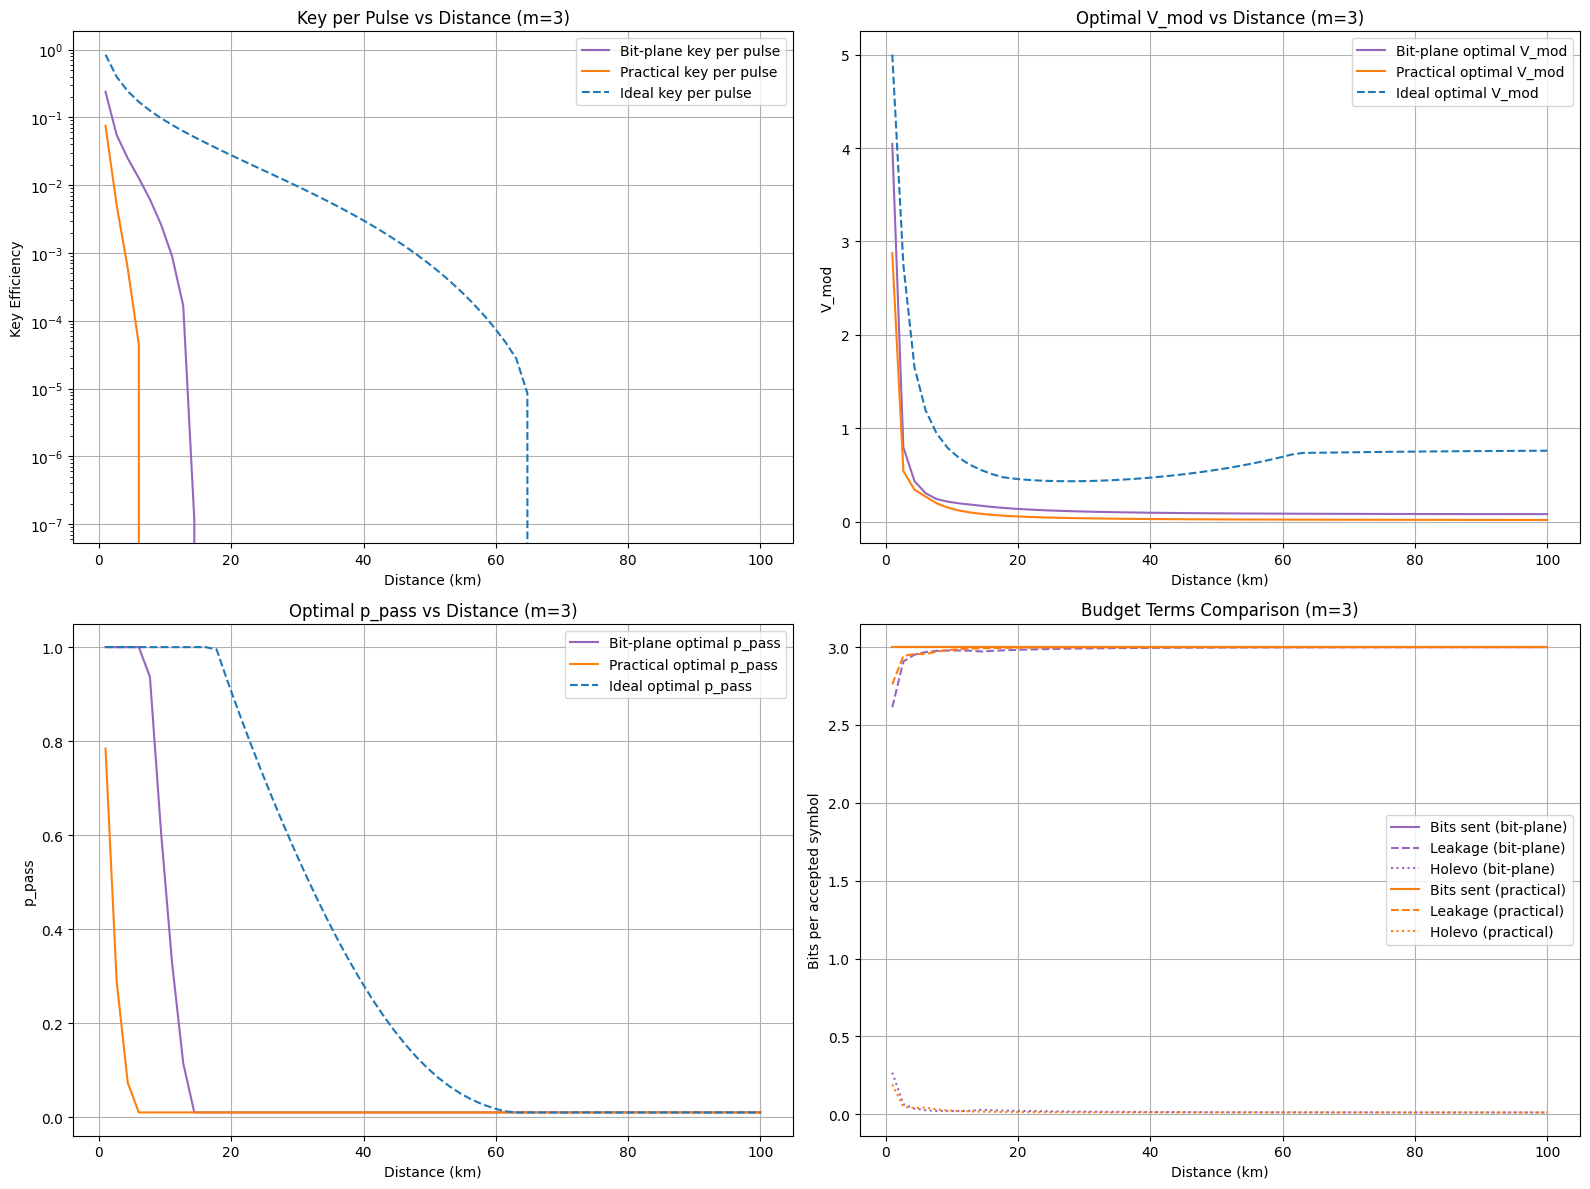

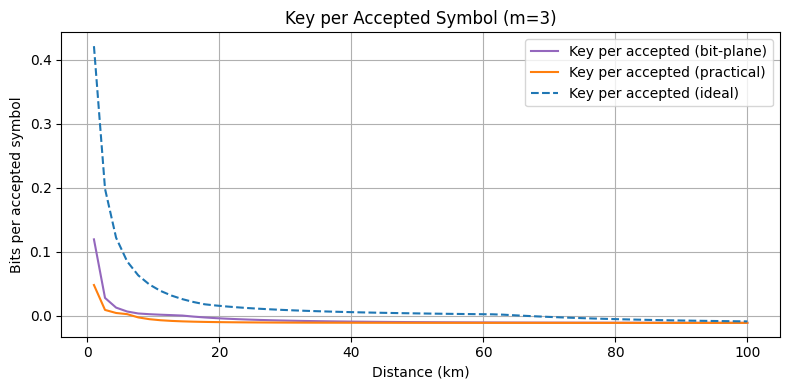

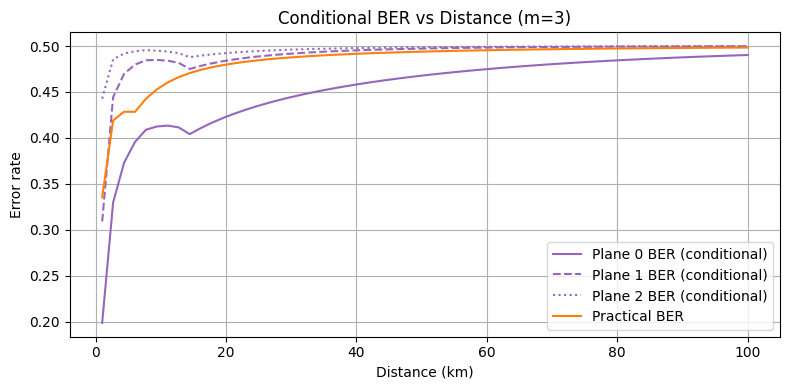

In [22]:
bit_plane_mode = 'one_code'
bit_plane_eta_c = practical_coding_efficiency

bit_plane_key_per_pulse_m3 = []
bit_plane_key_per_accepted_m3 = []
bit_plane_plane_ber_m3 = []
bit_plane_leakage_m3 = []
bit_plane_holevo_bounds_m3 = []
bit_plane_bits_sent_m3 = []
bit_plane_opt_v_mods_m3 = []
bit_plane_opt_p_passes_m3 = []
bit_plane_metrics_m3 = []

initial_guess_bit_plane_m3 = np.array([np.mean(v_mod_bounds), 0.8])
bounds_bit_plane_m3 = [v_mod_bounds, p_pass_bounds]

for distance in tqdm(distances, desc='Optimising bit-plane m=3'):
    transmittance = fibre_transmittance(distance)

    def evaluate_bit_plane_metrics_m3(v_mod_candidate: float, p_pass_candidate: float):
        gbsr_instance = GBSR(
            3,
            float(v_mod_candidate),
            transmittance,
            excess_noise,
            practical_coding_efficiency=practical_coding_efficiency,
        )
        tau_arr = gbsr_instance.build_equiprobable_tau()
        g_arr = gbsr_instance.generate_g_arr_from_p_pass(float(p_pass_candidate), tau_arr)
        metrics = gbsr_instance.evaluate_key_efficiency_via_bit_planes(
            tau_arr,
            g_arr,
            bit_assignment='Gray',
            mode=bit_plane_mode,
            eta_c=bit_plane_eta_c,
            include_delta_qct=False,
        )
        return dict(metrics), gbsr_instance

    def negative_bit_plane_m3(params):
        v_mod_candidate, p_pass_candidate = params
        v_mod_checked = float(np.clip(v_mod_candidate, *v_mod_bounds))
        p_pass_checked = float(np.clip(p_pass_candidate, *p_pass_bounds))
        try:
            metrics_candidate, _ = evaluate_bit_plane_metrics_m3(v_mod_checked, p_pass_checked)
        except Exception:
            return np.inf
        return -metrics_candidate['key_per_pulse']

    optimisation_result = minimize(
        negative_bit_plane_m3,
        x0=initial_guess_bit_plane_m3,
        bounds=bounds_bit_plane_m3,
        method='Powell',
    )

    if not optimisation_result.success or not np.isfinite(optimisation_result.fun):
        grid_v_mod = np.linspace(v_mod_bounds[0], v_mod_bounds[1], 25)
        grid_p_pass = np.linspace(p_pass_bounds[0], p_pass_bounds[1], 25)
        best_value = np.inf
        best_pair = None
        for v_candidate in grid_v_mod:
            for p_candidate in grid_p_pass:
                value = negative_bit_plane_m3((v_candidate, p_candidate))
                if value < best_value:
                    best_value = value
                    best_pair = (v_candidate, p_candidate)
        if best_pair is None:
            raise RuntimeError(f"Failed to find feasible parameters at distance {distance:.2f} km for bit-plane m=3")
        best_v_mod, best_p_pass = best_pair
    else:
        best_v_mod, best_p_pass = optimisation_result.x

    best_v_mod = float(np.clip(best_v_mod, *v_mod_bounds))
    best_p_pass = float(np.clip(best_p_pass, *p_pass_bounds))
    best_metrics, best_gbsr_instance = evaluate_bit_plane_metrics_m3(best_v_mod, best_p_pass)

    bit_plane_key_per_pulse_m3.append(best_metrics['key_per_pulse'])
    bit_plane_key_per_accepted_m3.append(best_metrics['key_per_accepted_symbol'])
    bit_plane_plane_ber_m3.append(best_metrics['e_k'])
    bit_plane_leakage_m3.append(best_metrics['leaked_info_per_symbol'])
    bit_plane_holevo_bounds_m3.append(best_metrics['holevo_bound'])
    bit_plane_bits_sent_m3.append(best_metrics['bits_sent_per_symbol'])
    bit_plane_opt_v_mods_m3.append(best_v_mod)
    bit_plane_opt_p_passes_m3.append(best_metrics['p_pass'])
    bit_plane_metrics_m3.append(best_metrics)

    initial_guess_bit_plane_m3 = np.array([best_v_mod, best_p_pass])

bit_plane_key_per_pulse_m3 = np.array(bit_plane_key_per_pulse_m3)
bit_plane_key_per_accepted_m3 = np.array(bit_plane_key_per_accepted_m3)
bit_plane_leakage_m3 = np.array(bit_plane_leakage_m3)
bit_plane_holevo_bounds_m3 = np.array(bit_plane_holevo_bounds_m3)
bit_plane_bits_sent_m3 = np.array(bit_plane_bits_sent_m3)
bit_plane_opt_v_mods_m3 = np.array(bit_plane_opt_v_mods_m3)
bit_plane_opt_p_passes_m3 = np.array(bit_plane_opt_p_passes_m3)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].plot(distances, bit_plane_key_per_pulse_m3, label='Bit-plane key per pulse', color='tab:purple')
axes[0, 0].plot(distances, practical_key_per_pulse_m3, label='Practical key per pulse', color='tab:orange')
axes[0, 0].plot(distances, key_per_pulse_m3, label='Ideal key per pulse', color='tab:blue', linestyle='--')
axes[0, 0].set_xlabel('Distance (km)')
axes[0, 0].set_ylabel('Key Efficiency')
axes[0, 0].set_title('Key per Pulse vs Distance (m=3)')
axes[0, 0].set_yscale('log')
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].plot(distances, bit_plane_opt_v_mods_m3, label='Bit-plane optimal V_mod', color='tab:purple')
axes[0, 1].plot(distances, practical_opt_v_mods_m3, label='Practical optimal V_mod', color='tab:orange')
axes[0, 1].plot(distances, optimal_v_mods_m3, label='Ideal optimal V_mod', color='tab:blue', linestyle='--')
axes[0, 1].set_xlabel('Distance (km)')
axes[0, 1].set_ylabel('V_mod')
axes[0, 1].set_title('Optimal V_mod vs Distance (m=3)')
axes[0, 1].legend()
axes[0, 1].grid(True)

axes[1, 0].plot(distances, bit_plane_opt_p_passes_m3, label='Bit-plane optimal p_pass', color='tab:purple')
axes[1, 0].plot(distances, practical_opt_p_passes_m3, label='Practical optimal p_pass', color='tab:orange')
axes[1, 0].plot(distances, optimal_p_passes_m3, label='Ideal optimal p_pass', color='tab:blue', linestyle='--')
axes[1, 0].set_xlabel('Distance (km)')
axes[1, 0].set_ylabel('p_pass')
axes[1, 0].set_title('Optimal p_pass vs Distance (m=3)')
axes[1, 0].legend()
axes[1, 0].grid(True)

axes[1, 1].plot(distances, bit_plane_bits_sent_m3, label='Bits sent (bit-plane)', color='tab:purple')
axes[1, 1].plot(distances, bit_plane_leakage_m3, label='Leakage (bit-plane)', color='tab:purple', linestyle='--')
axes[1, 1].plot(distances, bit_plane_holevo_bounds_m3, label='Holevo (bit-plane)', color='tab:purple', linestyle=':')
axes[1, 1].plot(distances, practical_bits_sent_m3, label='Bits sent (practical)', color='tab:orange')
axes[1, 1].plot(distances, practical_leakage_m3, label='Leakage (practical)', color='tab:orange', linestyle='--')
axes[1, 1].plot(distances, practical_holevo_bounds_m3, label='Holevo (practical)', color='tab:orange', linestyle=':')
axes[1, 1].set_xlabel('Distance (km)')
axes[1, 1].set_ylabel('Bits per accepted symbol')
axes[1, 1].set_title('Budget Terms Comparison (m=3)')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(distances, bit_plane_key_per_accepted_m3, label='Key per accepted (bit-plane)', color='tab:purple')
ax.plot(distances, practical_key_per_accepted_m3, label='Key per accepted (practical)', color='tab:orange')
ax.plot(distances, key_per_accepted_m3, label='Key per accepted (ideal)', color='tab:blue', linestyle='--')
ax.set_xlabel('Distance (km)')
ax.set_ylabel('Bits per accepted symbol')
ax.set_title('Key per Accepted Symbol (m=3)')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
for plane_idx in range(3):
    style = '-' if plane_idx == 0 else '--' if plane_idx == 1 else ':'
    ax.plot(distances, [plane[plane_idx] for plane in bit_plane_plane_ber_m3], label=f'Plane {plane_idx} BER (conditional)', color='tab:purple', linestyle=style)
ax.plot(distances, practical_error_rates_m3, label='Practical BER', color='tab:orange')
ax.set_xlabel('Distance (km)')
ax.set_ylabel('Error rate')
ax.set_title('Conditional BER vs Distance (m=3)')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


# Final Comparison of Key Efficiencies

Here, we plot all the key efficiencies together, on one plot. Solid lines for bit-plane key efficiency with one code, dotted lines for 'practical' key efficiency with one code, and dashed lines for 'optimal' key efficiency.

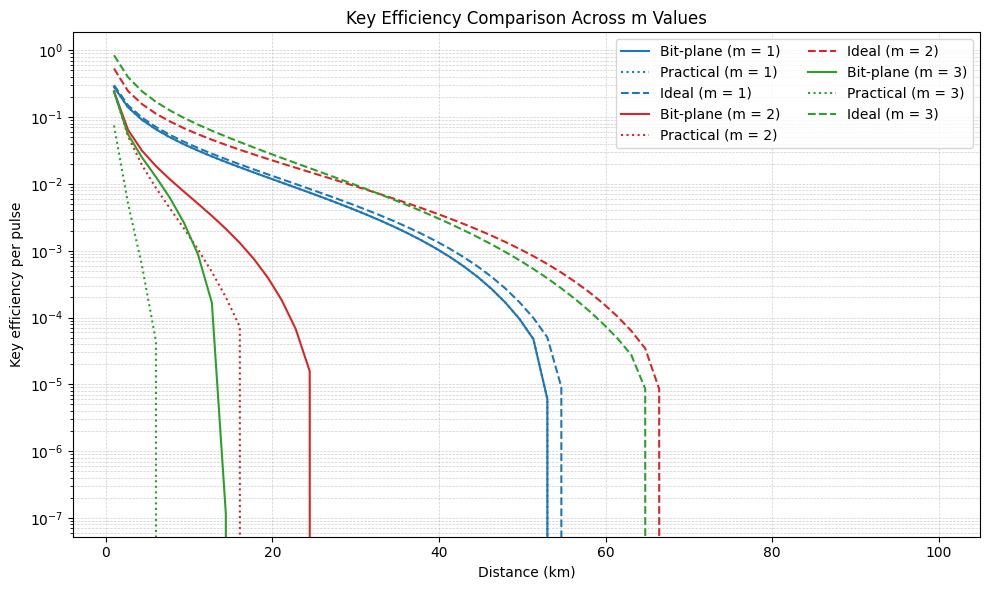

In [23]:
color_map = {1: 'tab:blue', 2: 'tab:red', 3: 'tab:green'}
label_map = {1: 'm = 1', 2: 'm = 2', 3: 'm = 3'}

fig, ax = plt.subplots(figsize=(10, 6))

for m in (1, 2, 3):
    # Bit-plane (solid)
    bit_plane_series = globals()[f'bit_plane_key_per_pulse_m{m}']
    ax.plot(distances, bit_plane_series, color=color_map[m], linestyle='-', label=f'Bit-plane ({label_map[m]})')
    # Practical (dotted)
    practical_series = globals()[f'practical_key_per_pulse_m{m}']
    ax.plot(distances, practical_series, color=color_map[m], linestyle=':', label=f'Practical ({label_map[m]})')
    # Ideal (dashed)
    ideal_series = globals()[f'key_per_pulse_m{m}']
    ax.plot(distances, ideal_series, color=color_map[m], linestyle='--', label=f'Ideal ({label_map[m]})')

ax.set_xlabel('Distance (km)')
ax.set_ylabel('Key efficiency per pulse')
ax.set_title('Key Efficiency Comparison Across m Values')
ax.set_yscale('log')
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.6)
ax.legend(ncol=2)
plt.tight_layout()
plt.show()
